# Simulations light inter

In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(".") 
from plot_outputs import *

sys.path.append("../data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

# from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import compute_extinction_coef, concat_usm
# from openalea.plantgl.all import Color3, Material, Scene  # noqa: F401


# %gui qt

In [2]:
stics_color = "orange"
archicrop_color = "green"

In [3]:
tec_file_xml='../data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plt_file_xml='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
weather_file = '../data/usms_STICS/v10/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [44]:
n = 0
file = f"../simulations_ArchiCrop/results_light_inter_{n}.nc"
ds = xr.open_dataset(file)
print(len(ds.realized_la.values[0][0][0][0]), len(ds.realized_la.values[0][0][1][0]))

89 89


In [ ]:
def open_ds(n_cpu):
    file_list = []
    for cpu in range(n_cpu):
        file_list.append(f"../simulations_ArchiCrop/results_light_inter_{cpu}.nc")
    ds = concat_usm(file_list)
    return ds


In [17]:
usms = [1,2,3,4,5,6,10,12,14,16,18] #,20,22,24,26]
usms_dict = dict(zip(range(len(usms)),usms))
n_cpu = len(usms)
ds = open_ds(n_cpu)
ds

<xarray.Dataset> Size: 417kB
Dimensions:                 (usm: 11, algo: 2, plant: 2, time: 89, id: 1)
Coordinates:
  * usm                     (usm) object 88B 'usm_1' 'usm_2' ... 'usm_18'
  * algo                    (algo) object 16B '2.5D' 'Beer'
  * plant                   (plant) object 16B 'maize' 'sorghum'
  * time                    (time) int32 356B 0 1 2 3 4 5 ... 83 84 85 86 87 88
  * id                      (id) int32 4B 1
Data variables: (12/44)
    thermal_time            (usm, algo, plant, time) float64 31kB nan ... 1.1...
    lai_stics               (usm, algo, plant, time) float64 31kB nan ... 5.0...
    sen_lai_stics           (usm, algo, plant, time) float64 31kB nan ... 1.369
    height_stics            (usm, algo, plant, time) float64 31kB nan ... 249.1
    inc_par                 (usm, algo, plant, time) float64 31kB nan ... 8.345
    abs_par_stics           (usm, algo, plant, time) float64 31kB nan ... 0.5675
    ...                      ...
    tiller_delay            (usm, algo, plant, id) int32 176B 1 1 1 1 ... 1 1 1
    reduction_factor        (usm, algo, plant, id) float64 352B 1.0 0.5 ... 0.5
    tropism_coefficient     (usm, algo, plant, id) float64 352B 0.05 ... 0.12
    leaf_lifespan           (usm, algo, plant, id) float64 352B 280.0 ... 280.0
    leaf_lifespan_early     (usm, algo, plant, id) float64 352B 224.0 ... 224.0
    domain_area             (usm, algo) float64 176B 1.28 1.28 ... 1.28 1.28

In [20]:
ds.domain_area.values[0][0]

np.float64(1.28)

In [39]:
usms_str = ds.usm.values
algos = ds.algo.values
plants = ds.plant.values
dates = ds.time.values[:-1]
# dates = pd.to_datetime(dates)
# dates = dates.strftime('%Y-%m-%d')

thermal_time = {usm: {algo: {plant: ds.thermal_time.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
leaf_area_plant = {usm: {algo: {plant: ds.lai_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
sen_leaf_area_plant = {usm: {algo: {plant: ds.sen_lai_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
height_canopy = {usm: {algo: {plant: ds.height_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_incident = {usm: {algo: {plant: ds.inc_par.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_stics = {usm: {algo: {plant: ds.abs_par_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
density = {usm: {algo: {plant: ds.density.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
domain_area = {usm: {algo: ds.domain_area.values[u][a] for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

pot_la = {usm: {algo: {plant: ds.pot_la.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
pot_h = {usm: {algo: {plant: ds.pot_h.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
realized_la = {usm: {algo: {plant: ds.realized_la.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
realized_h = {usm: {algo: {plant: ds.realized_h.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

nrj_crop = {usm: {algo: {plant: [nrj/par_incident[usm][algo][plant][t]/domain_area[usm][algo] for t,nrj in enumerate(ds.nrj_per_leaf.values[u][a][p][0][:-1])] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}


In [33]:
dates

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88], dtype=int32)

In [ ]:
# nrj_leaf[1][1][1][1][50]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])

In [ ]:
# insertion_angle = {id:i for id,i in insertion_angle.items()}
# curvature = {id:i for id,i in curvature.items()}
# nb_phy = {id:i for id,i in nb_phy.items()}

# for id,nrj in nrj_leaf.items():
#     for i,t in enumerate(nrj):
#         for j,leaf in enumerate(t):
#             if leaf == 0.0 or math.isnan(leaf):
#                 print(nrj_leaf[id][i])
#                 nrj_leaf[id][i] = t[:j]
#                 break

# nrj_crop = {id:[np.nansum([leaf for i,leaf in enumerate(t) if i < nb_phy[id]])*density for t in nrj] for id,nrj in nrj_leaf.items()}

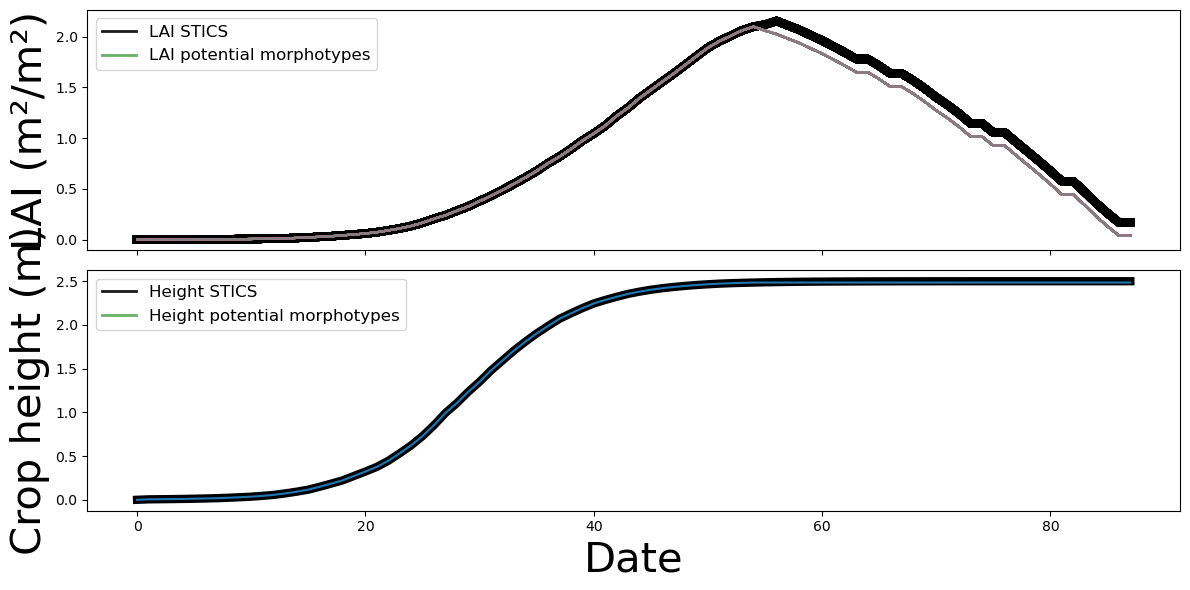

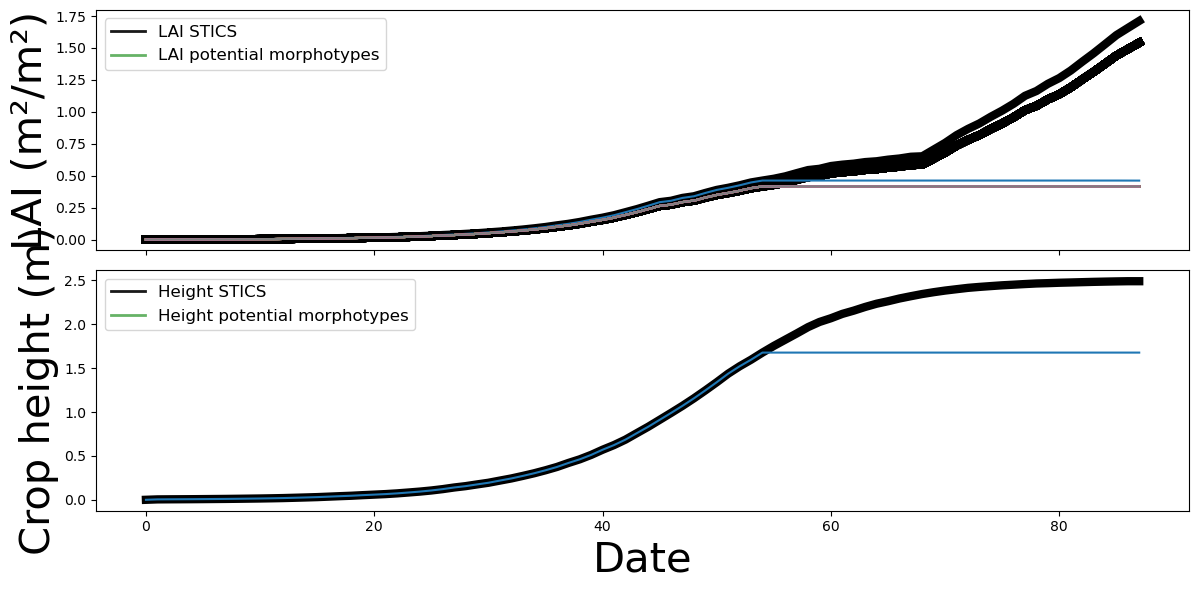

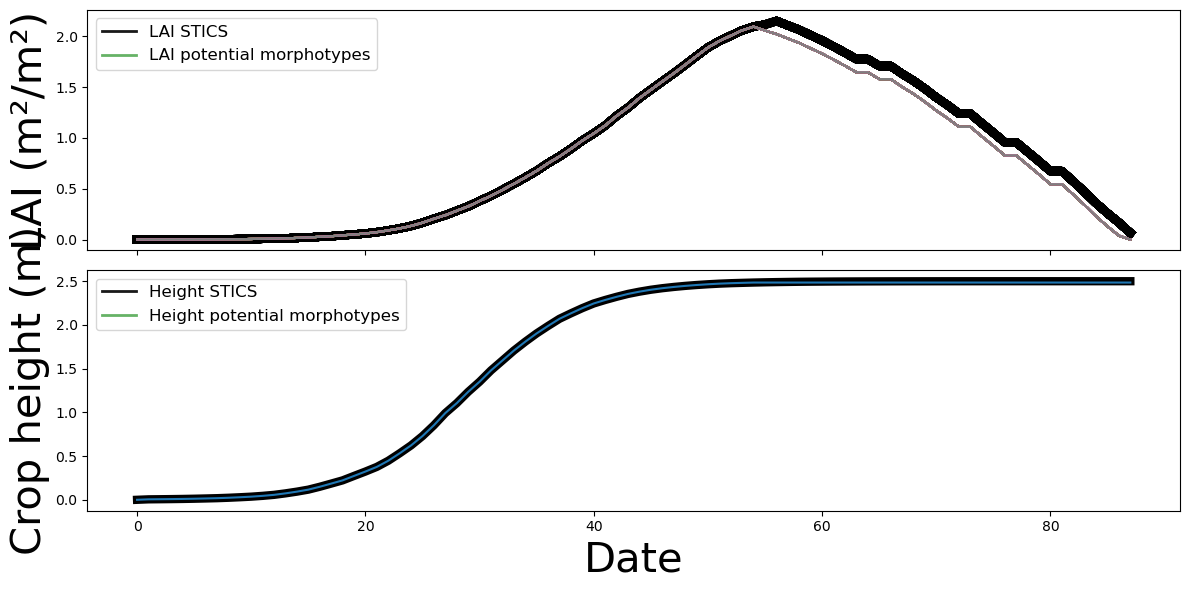

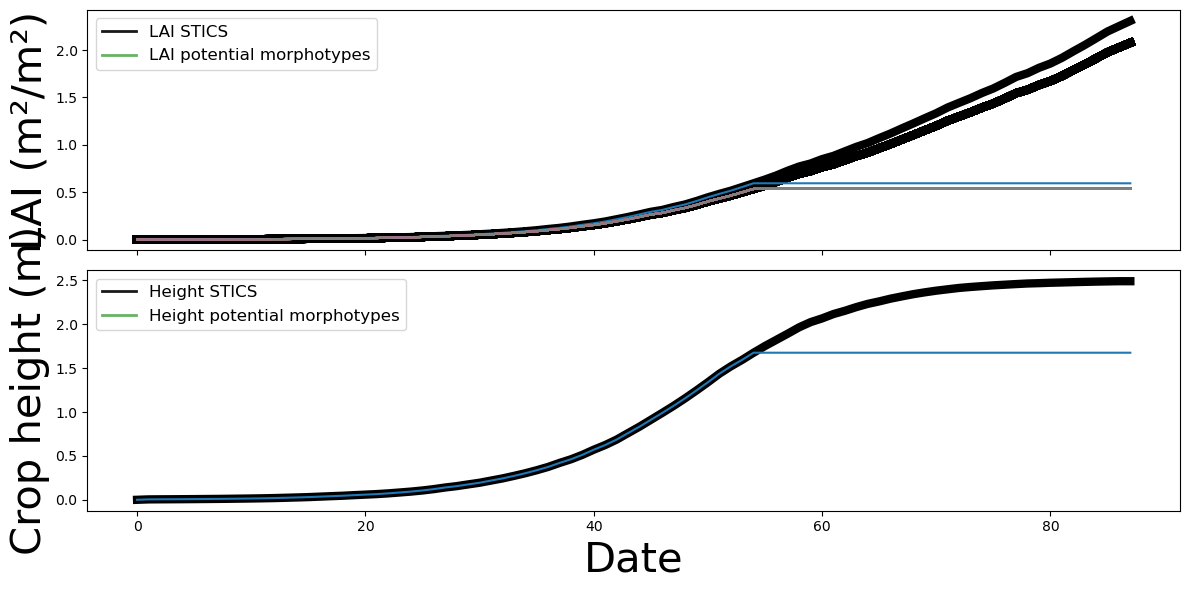

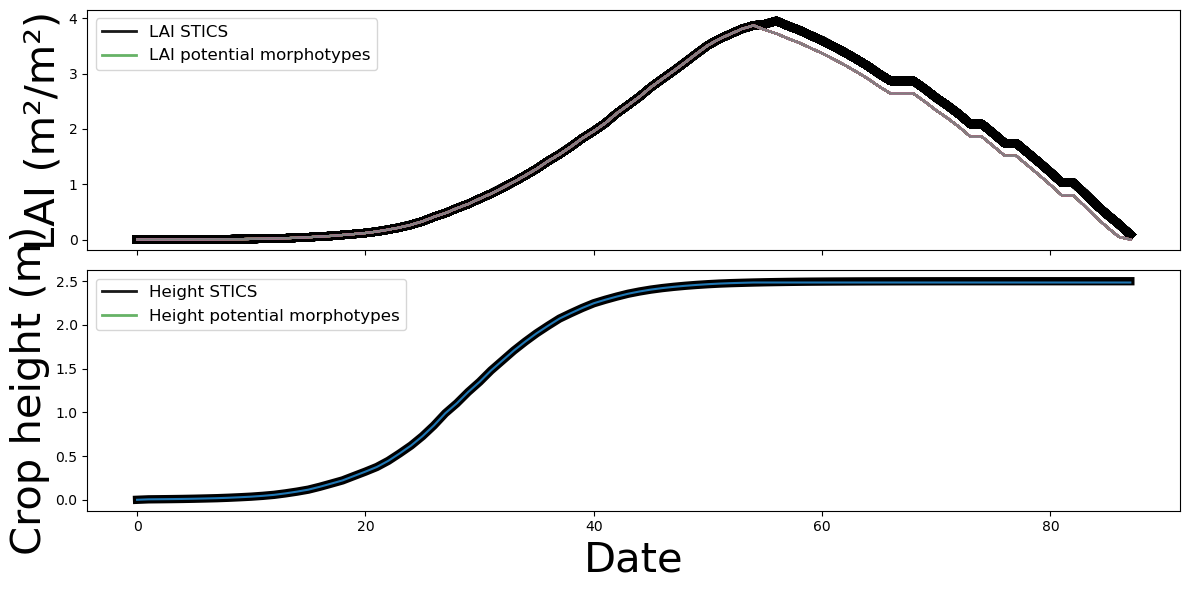

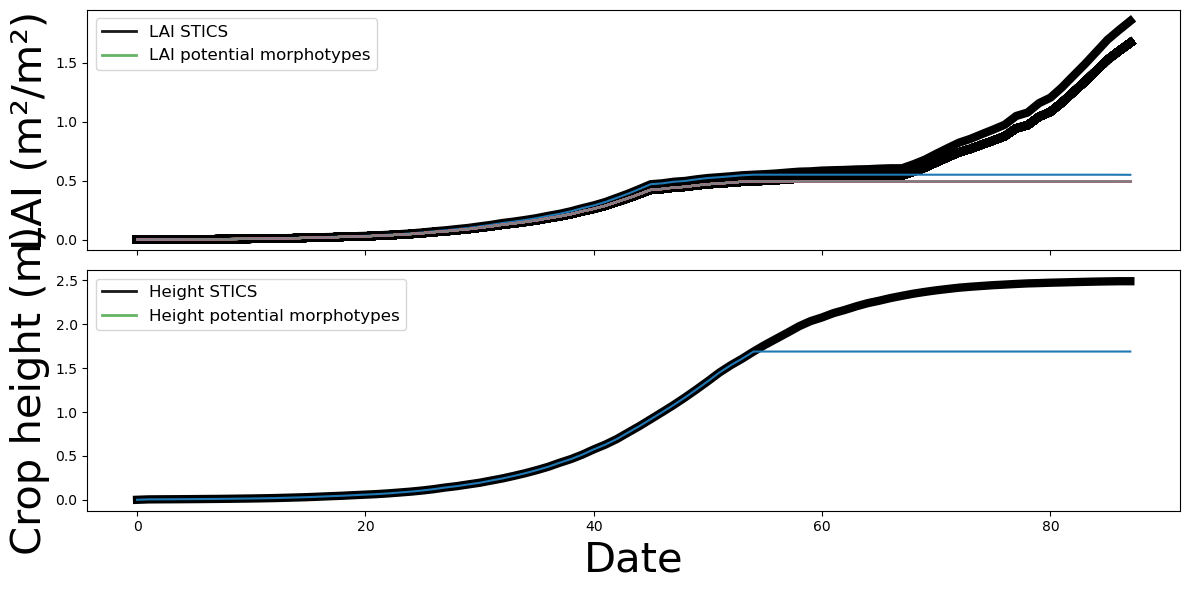

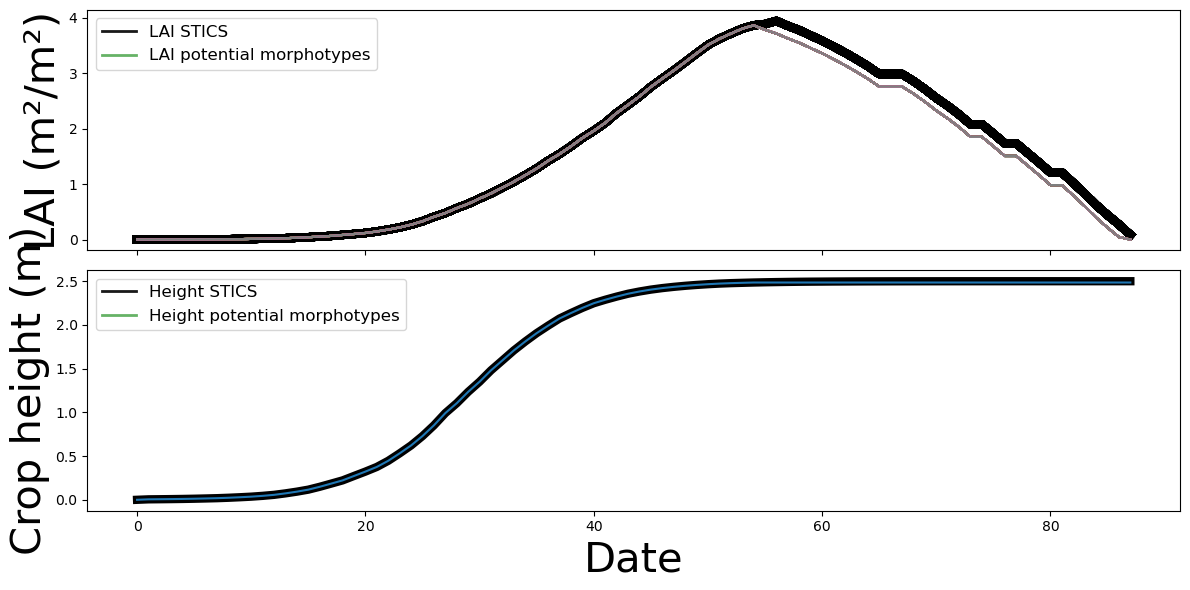

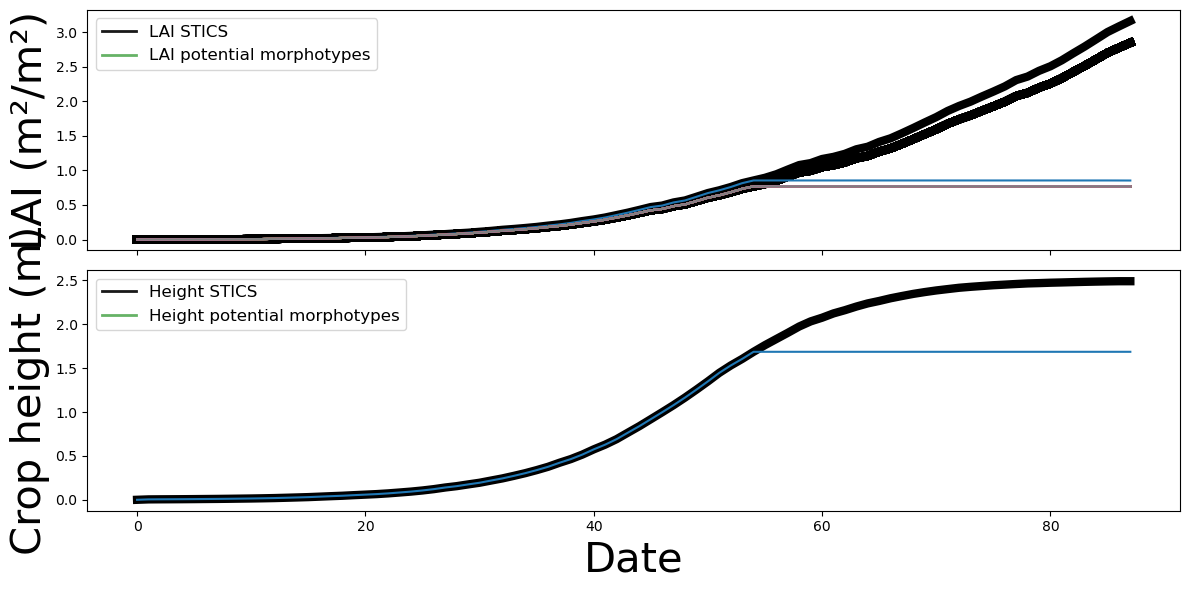

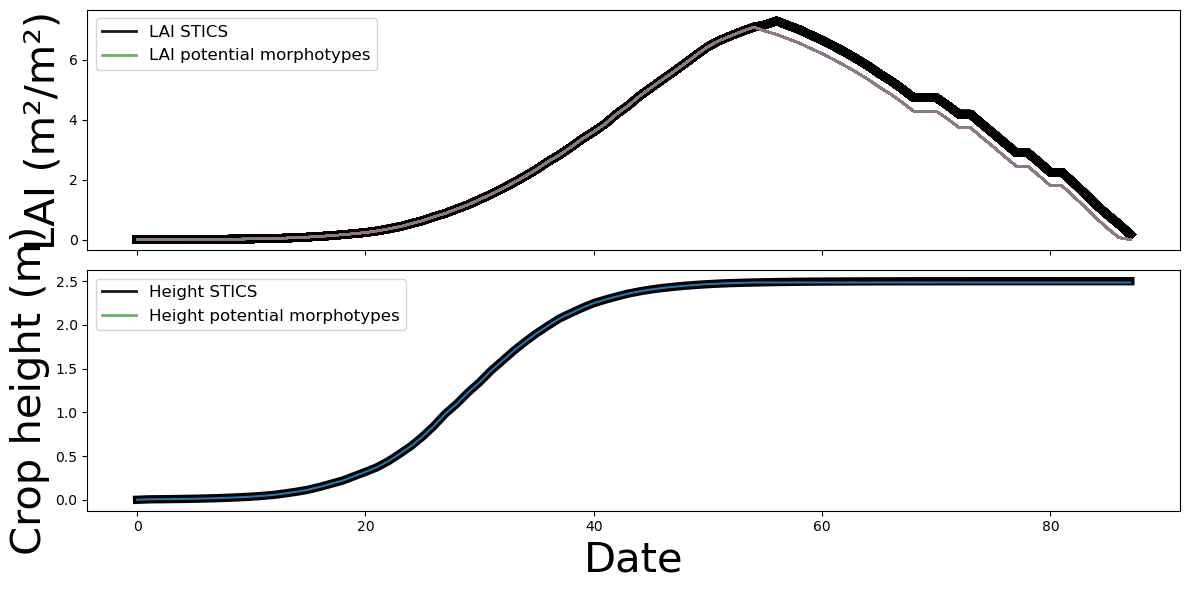

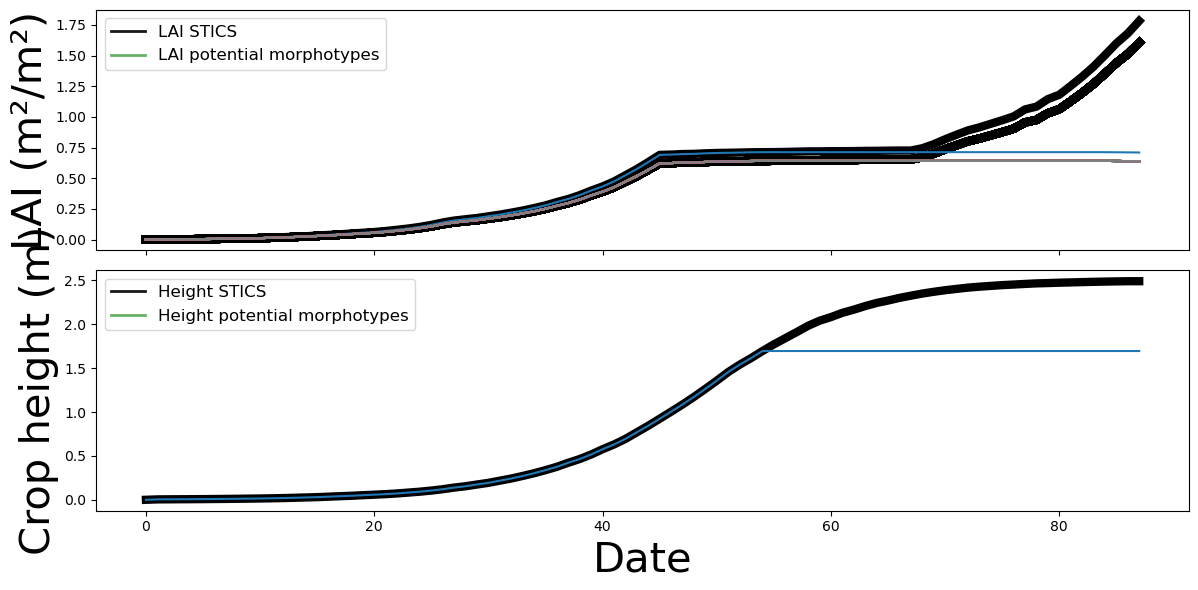

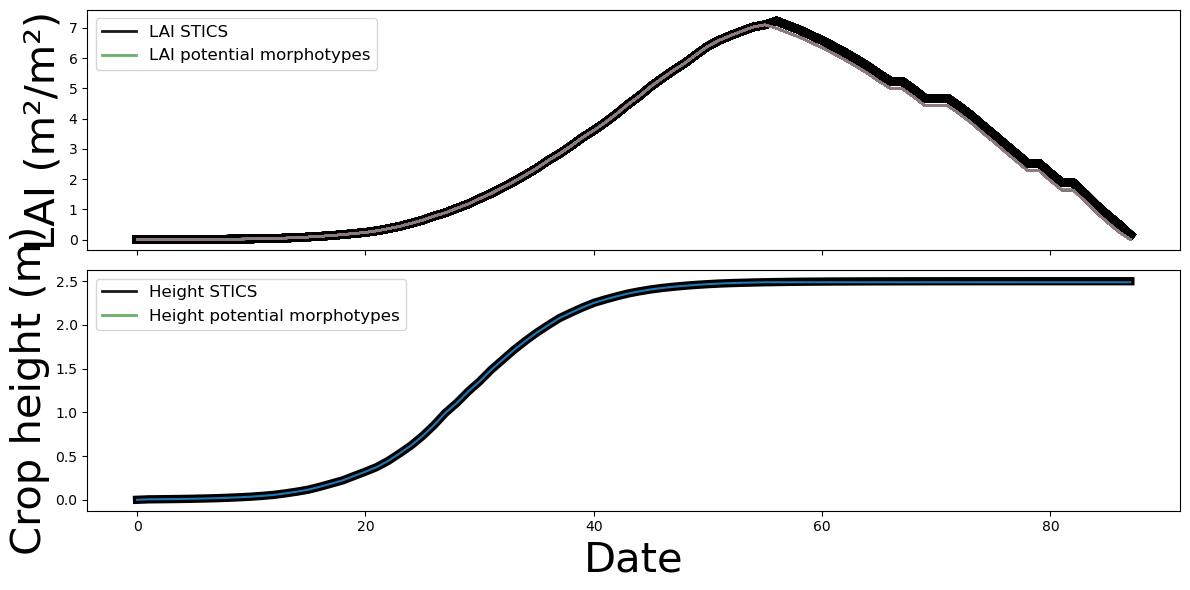

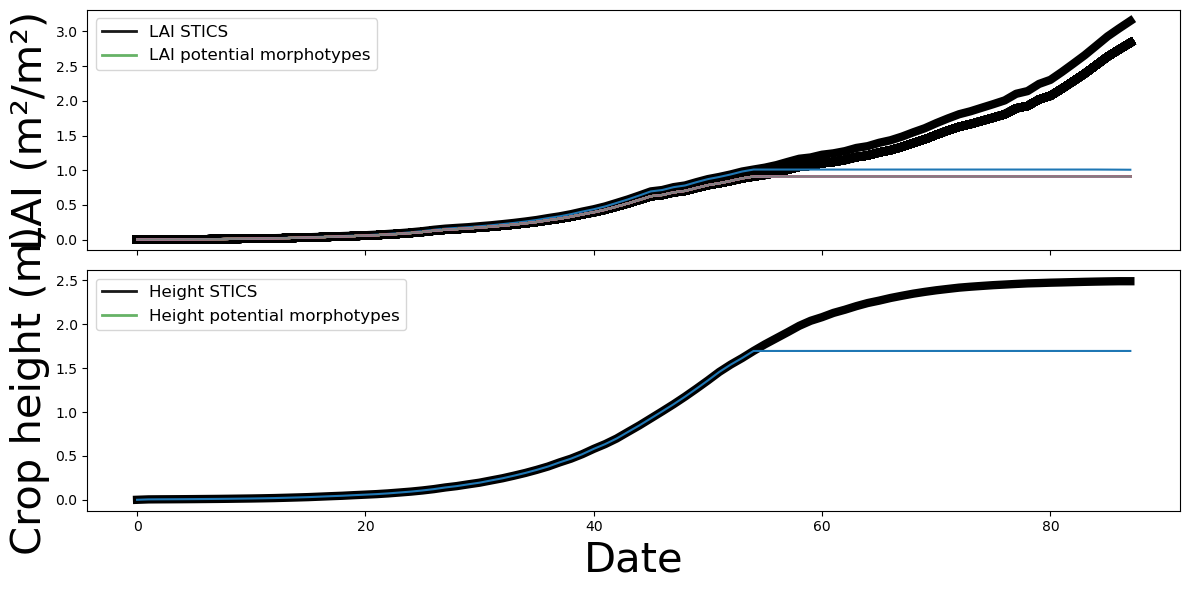

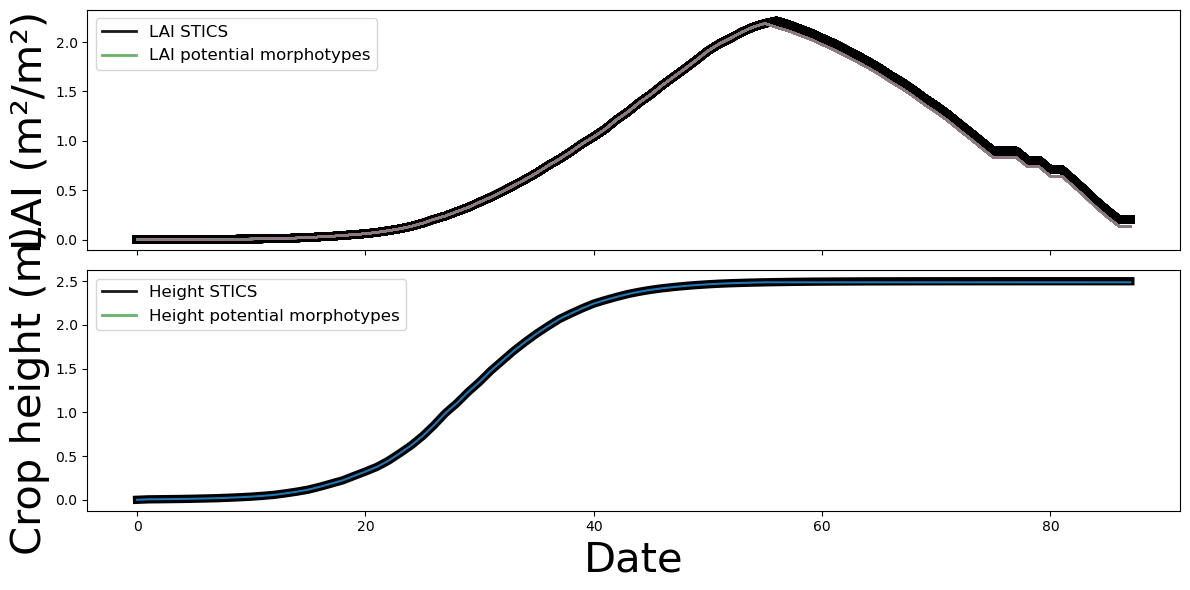

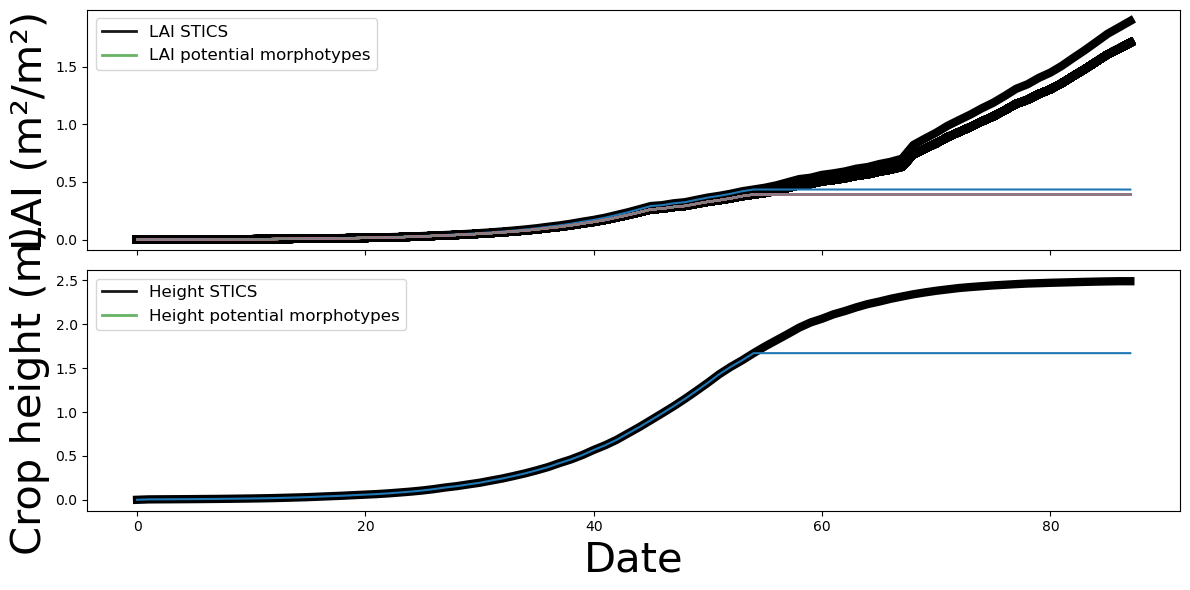

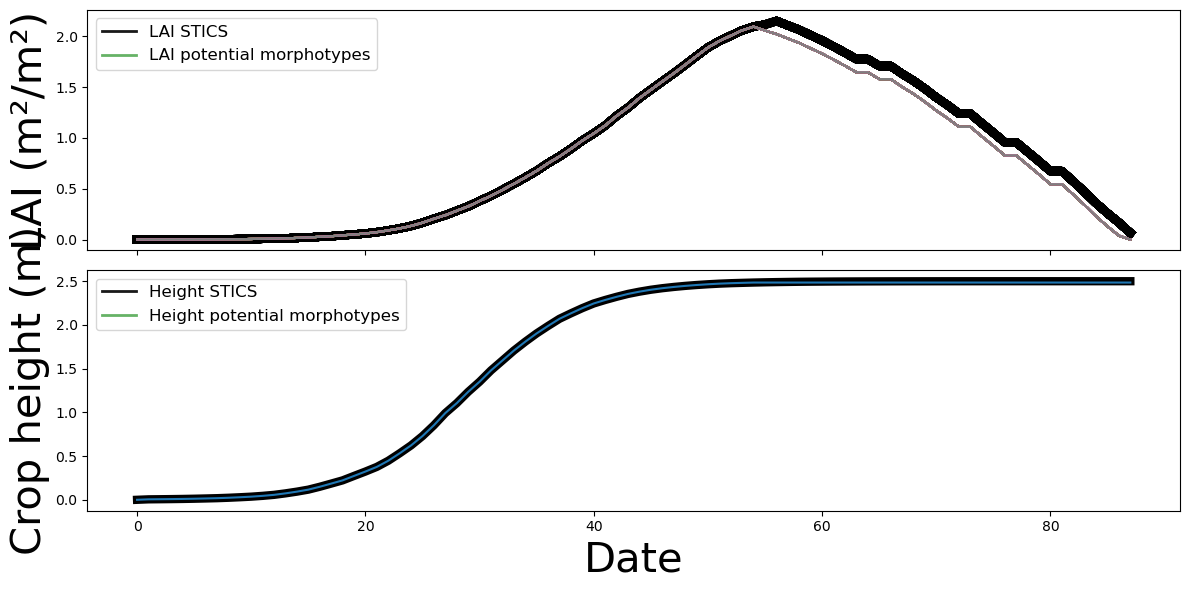

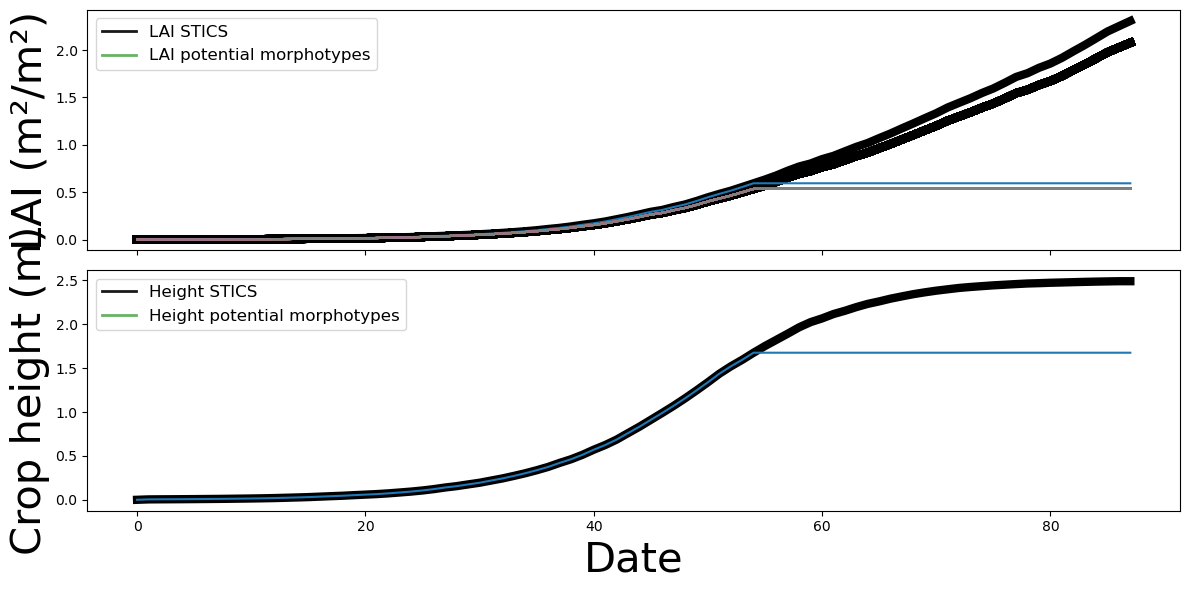

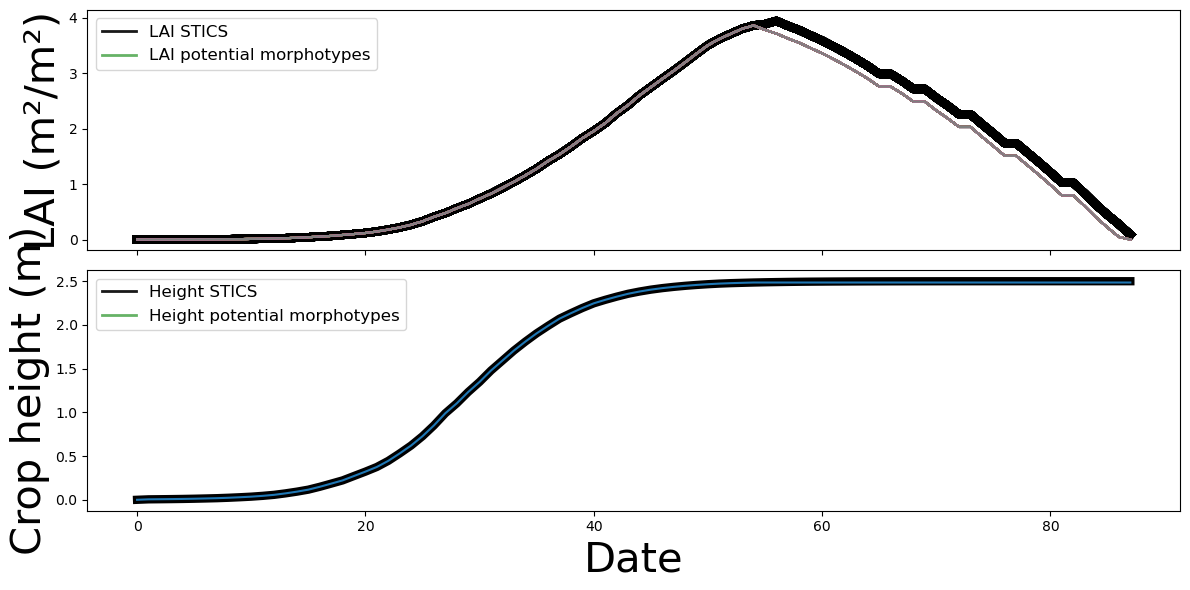

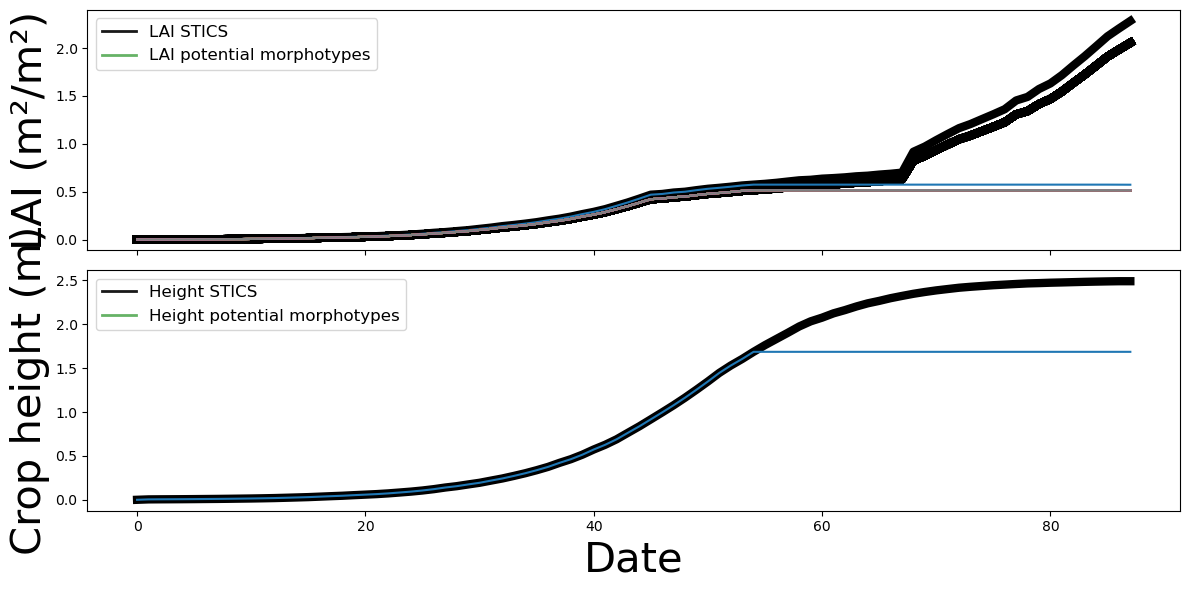

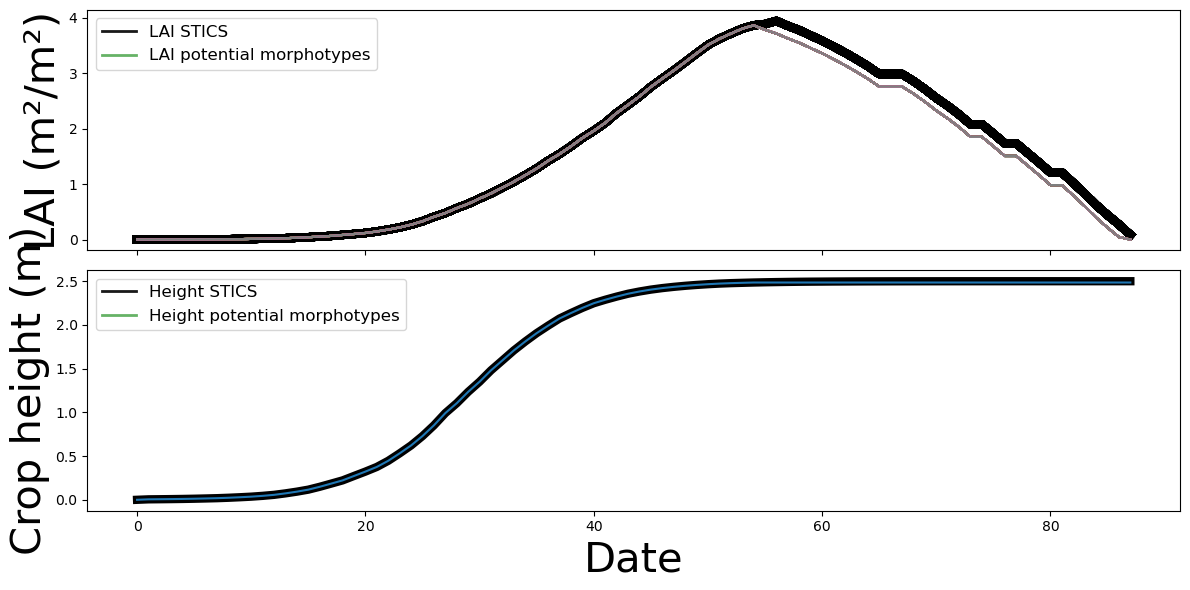

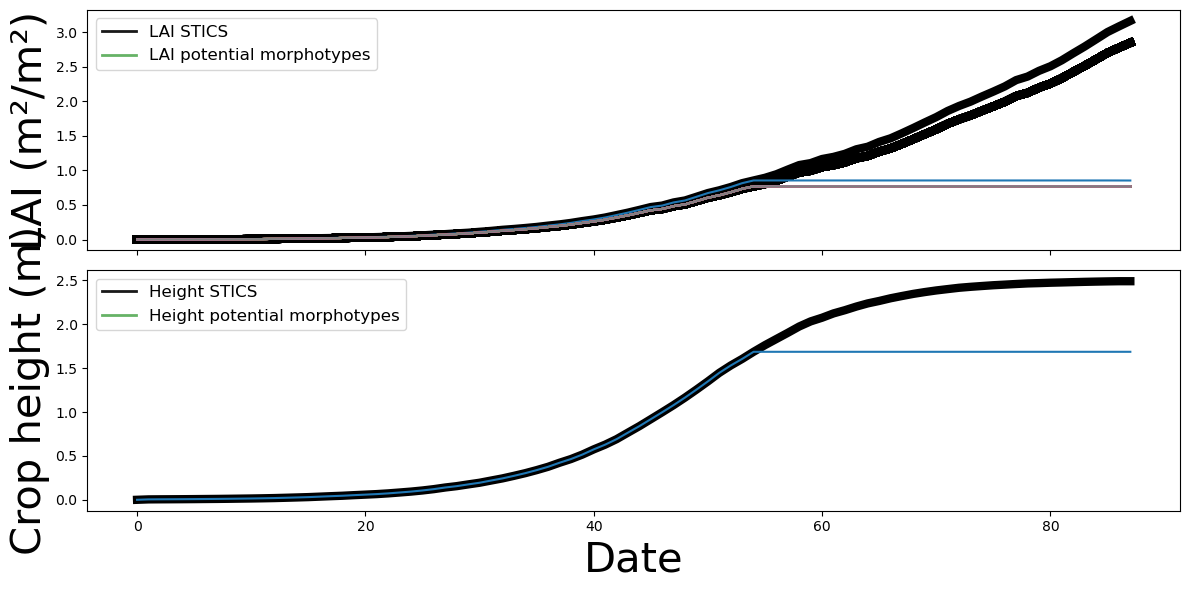

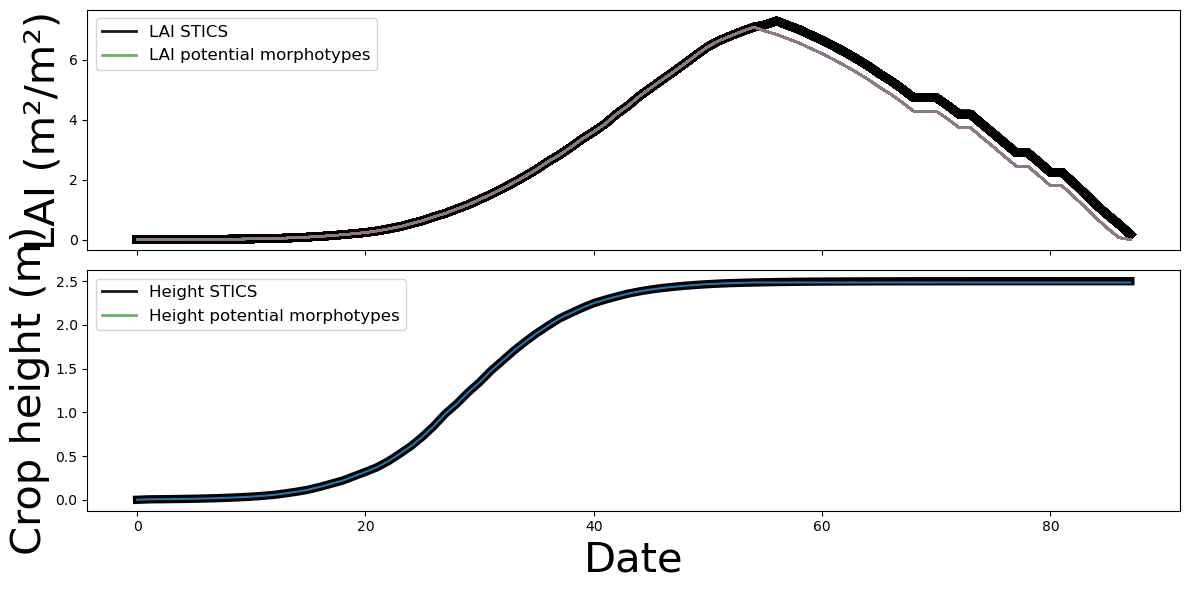

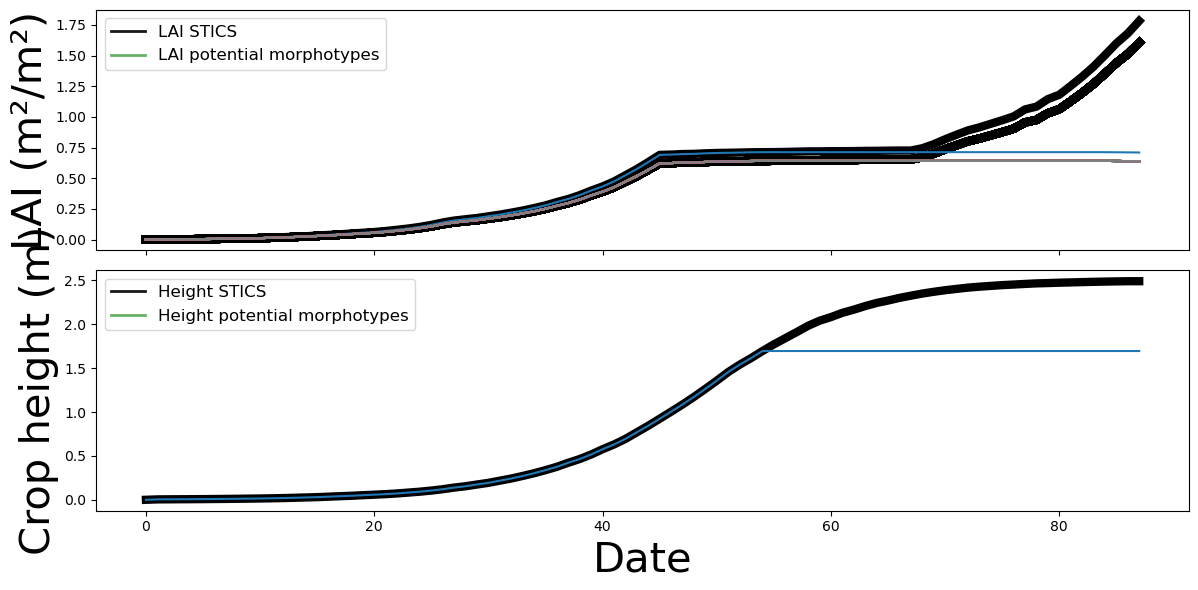

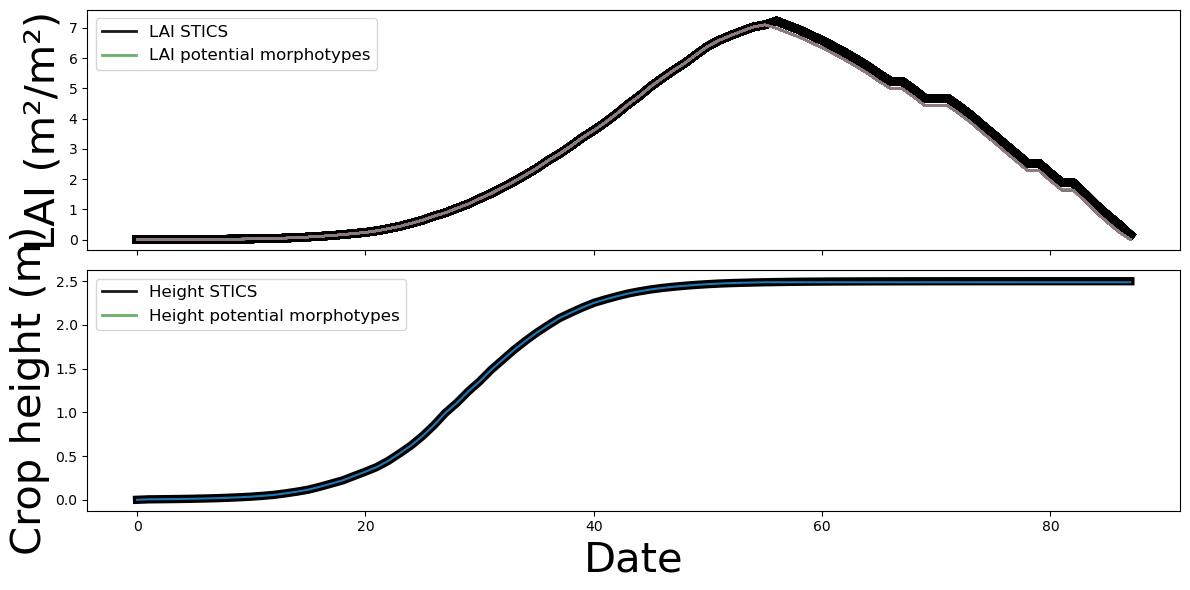

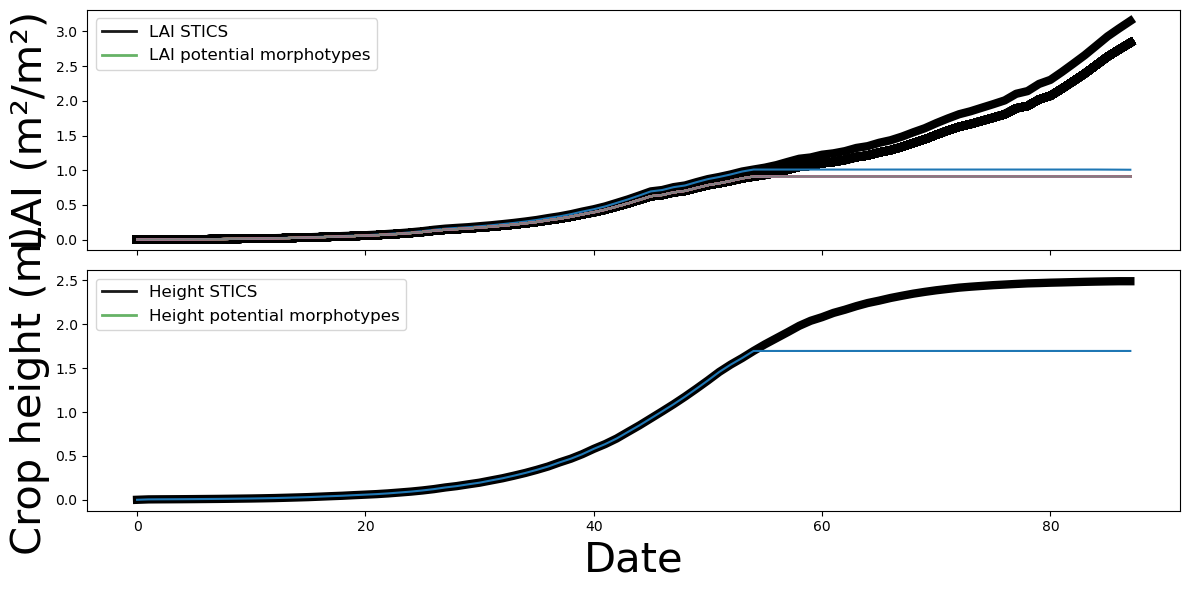

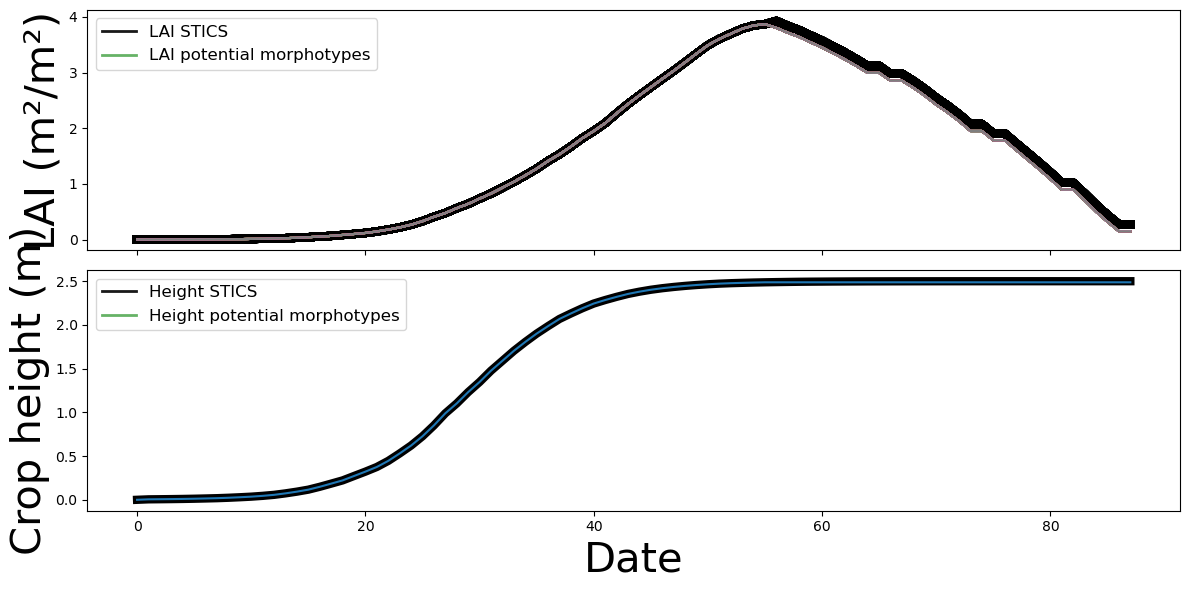

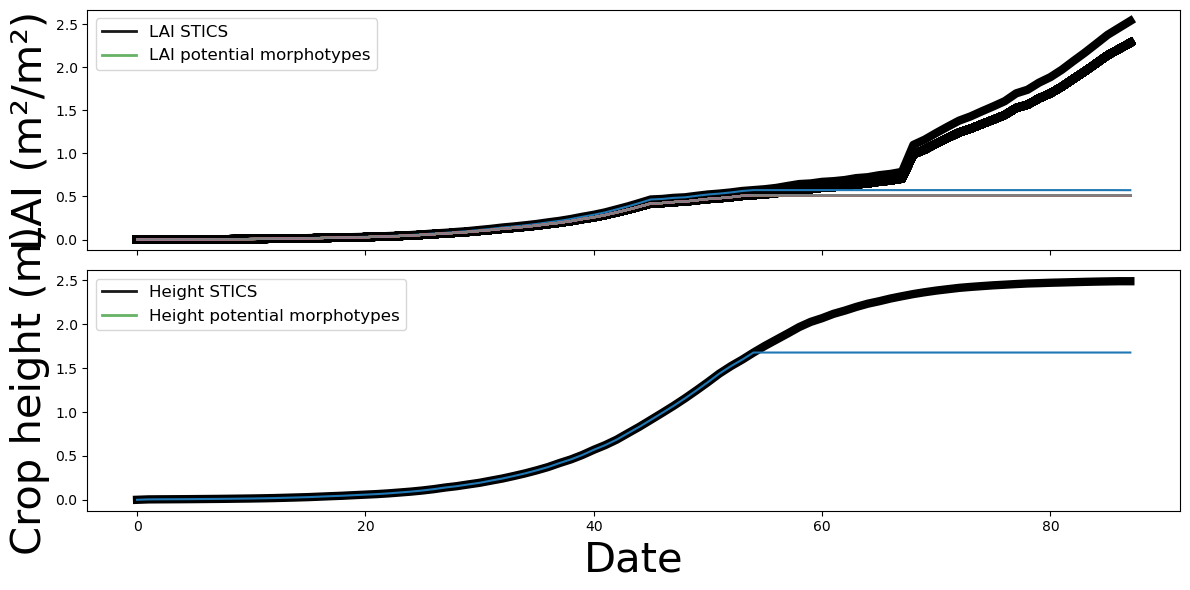

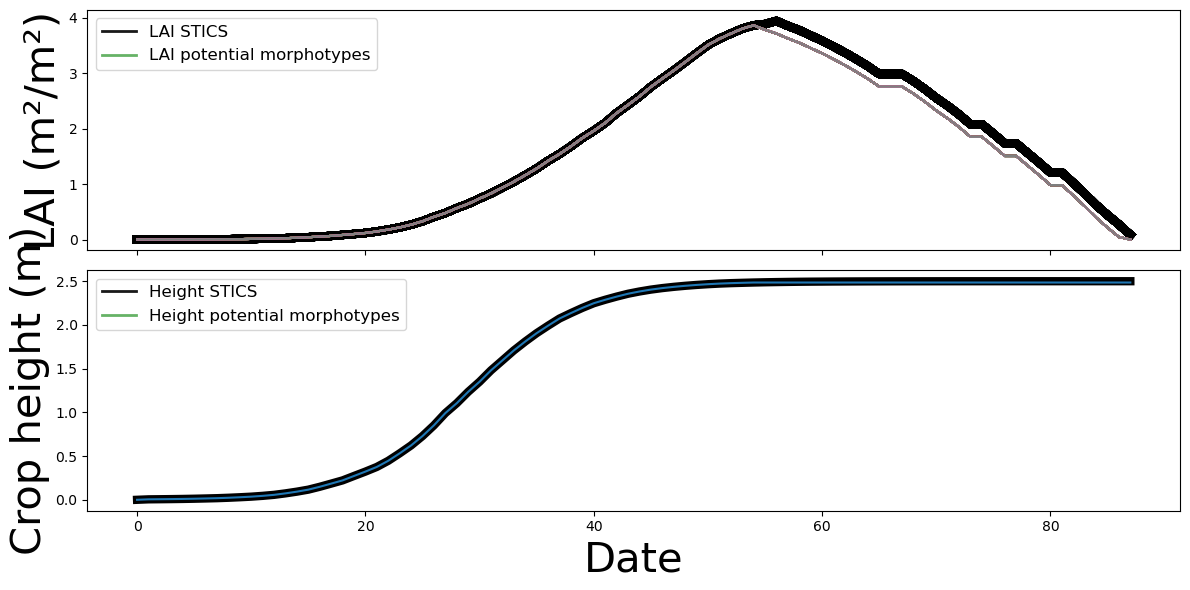

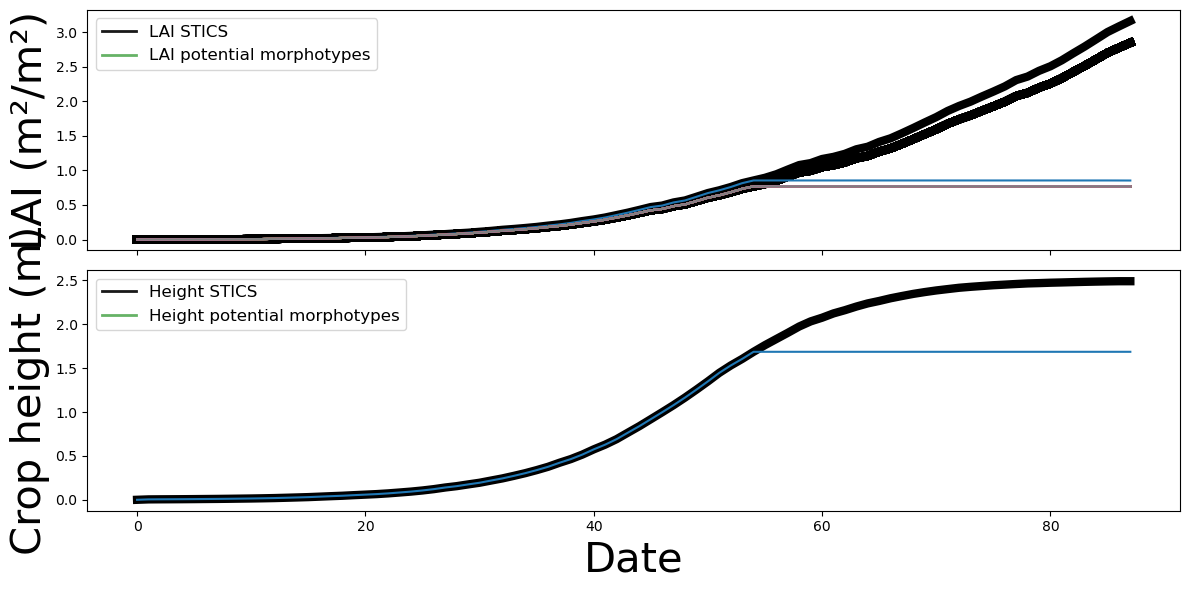

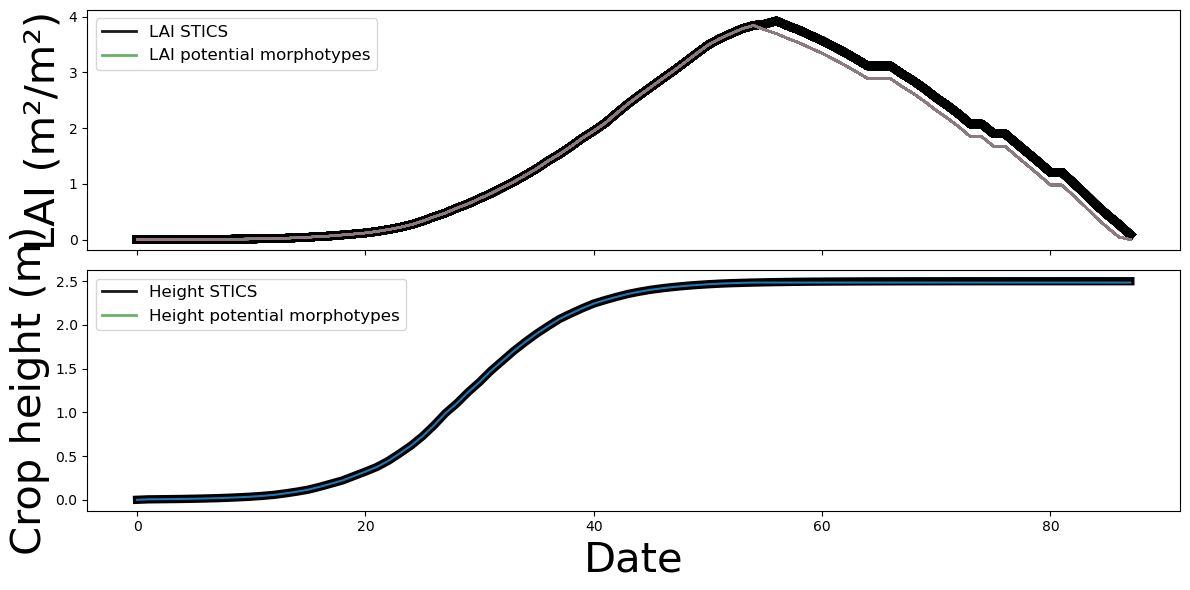

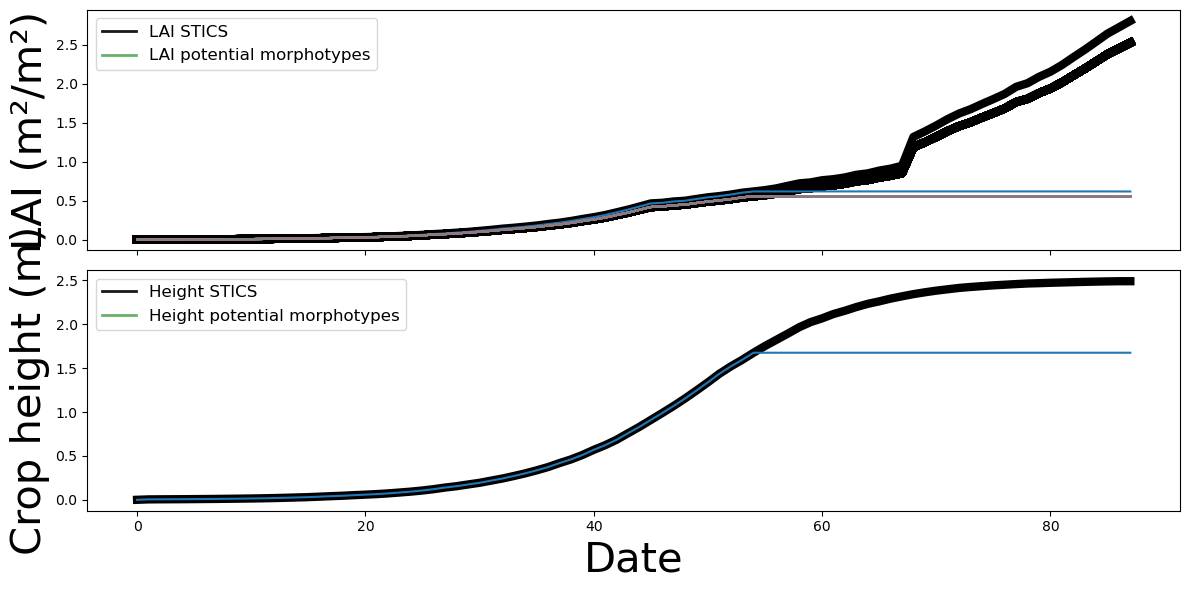

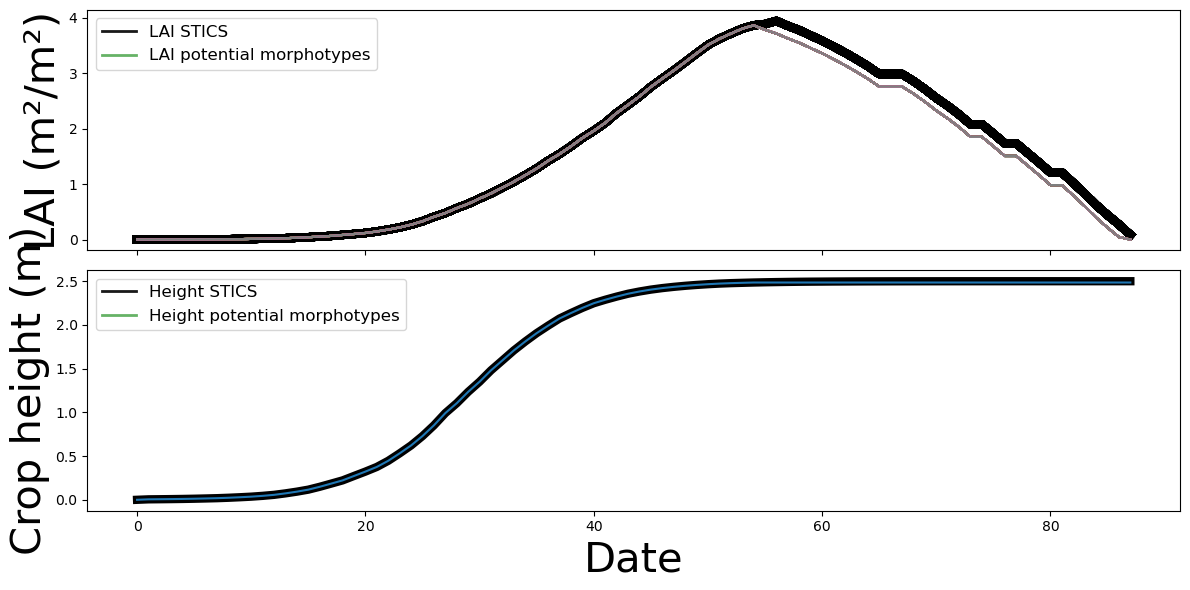

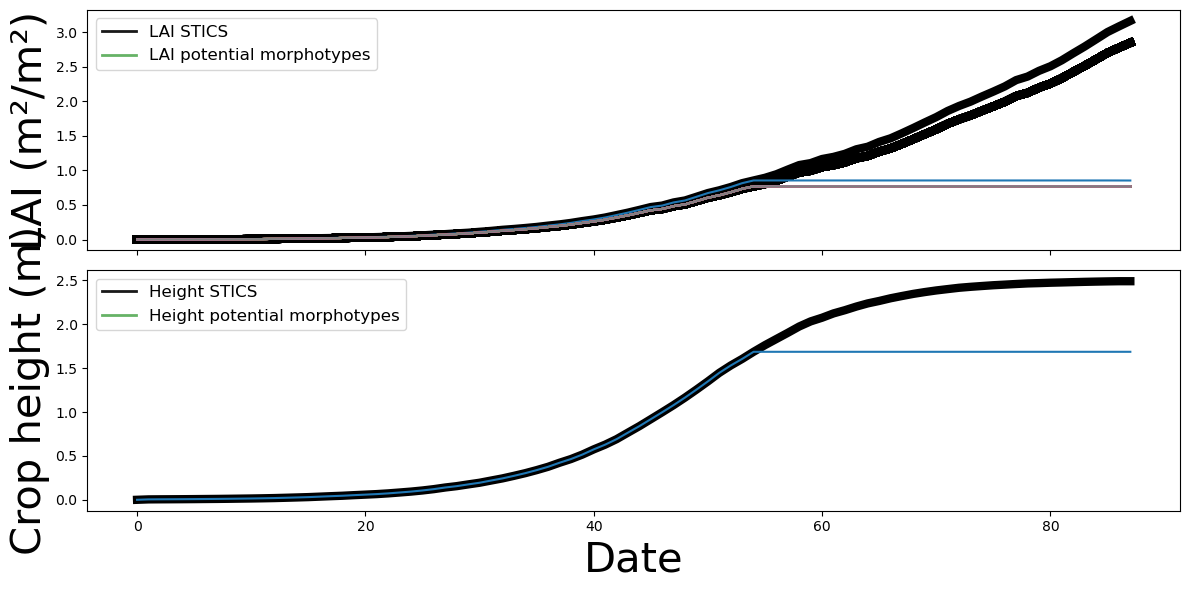

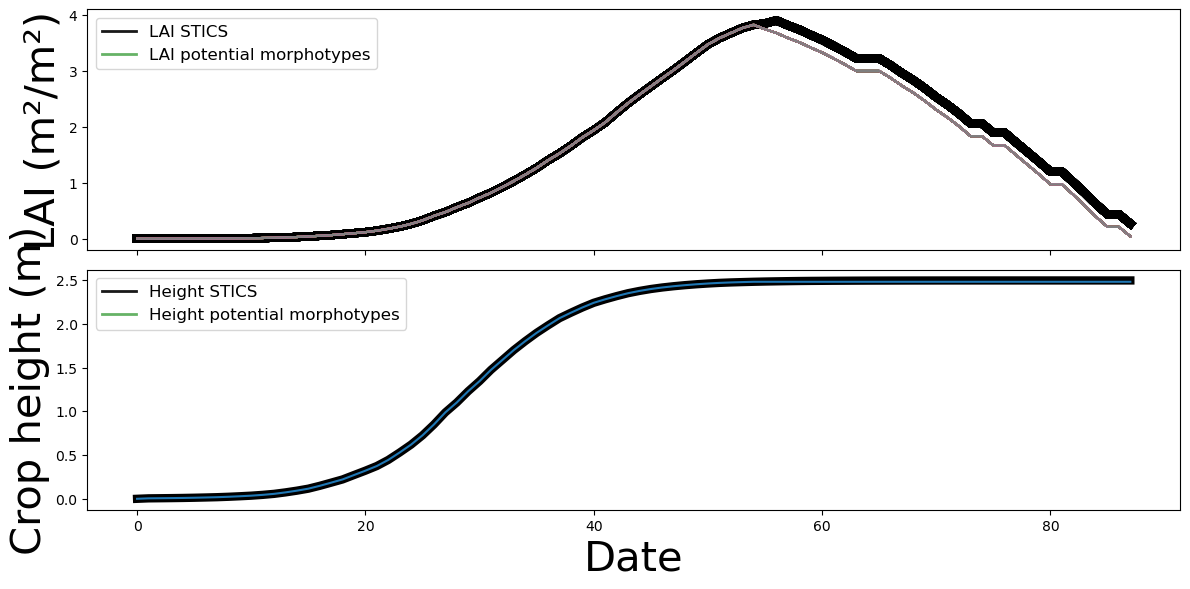

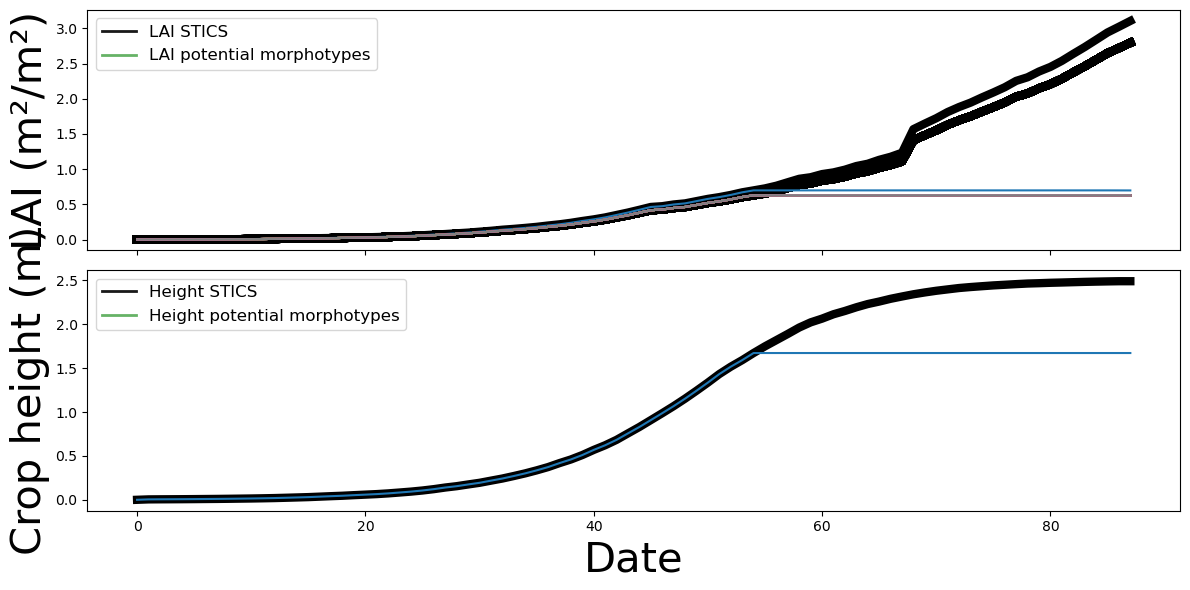

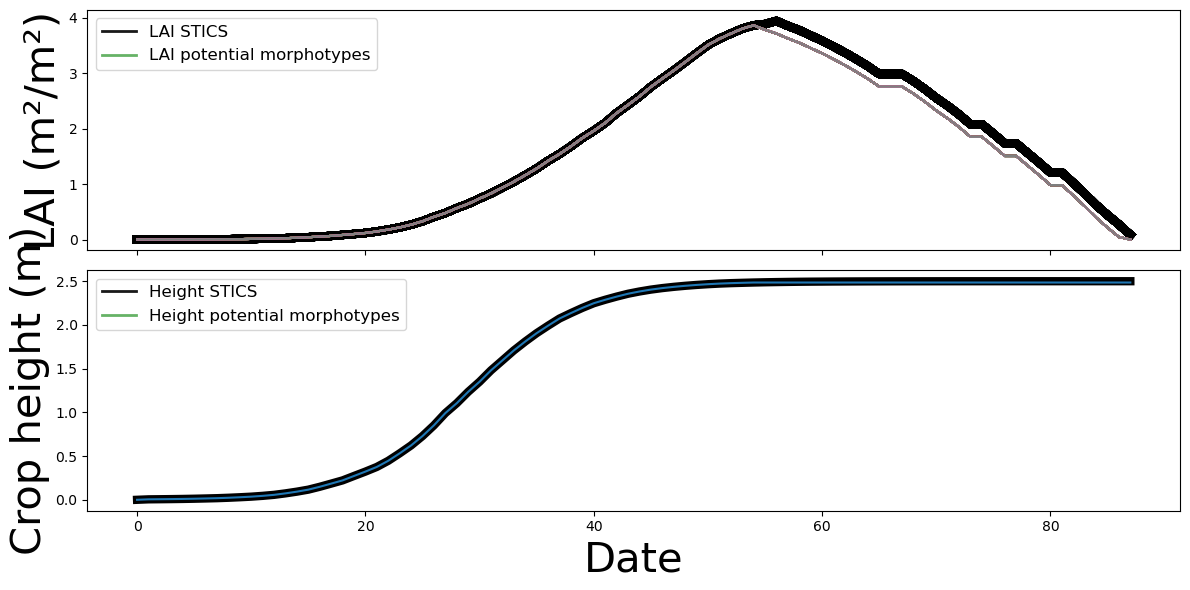

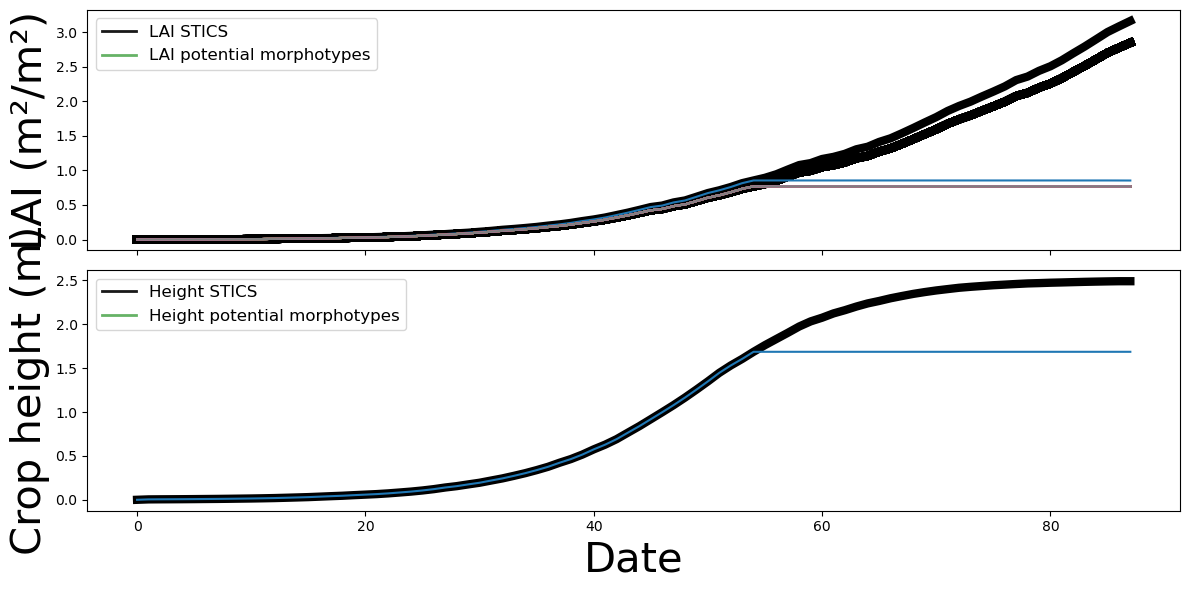

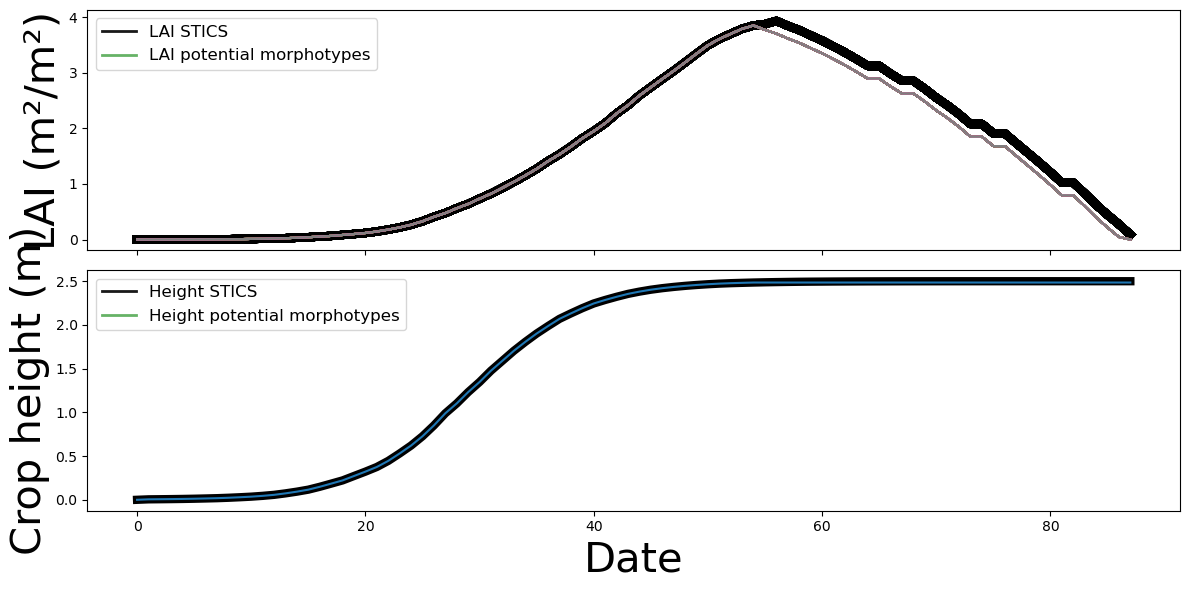

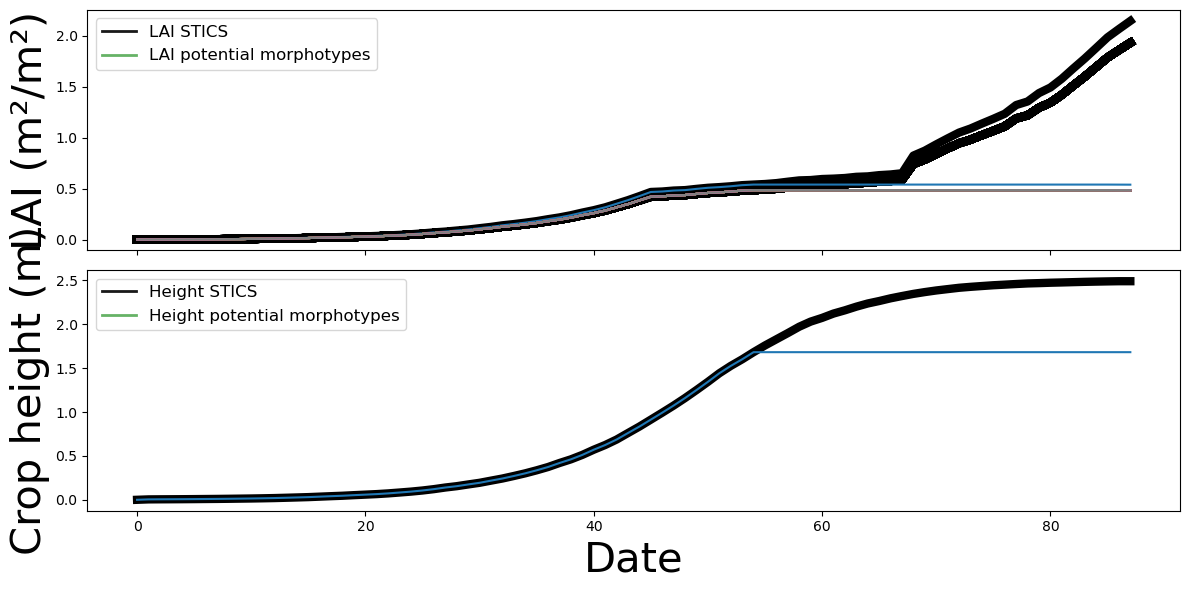

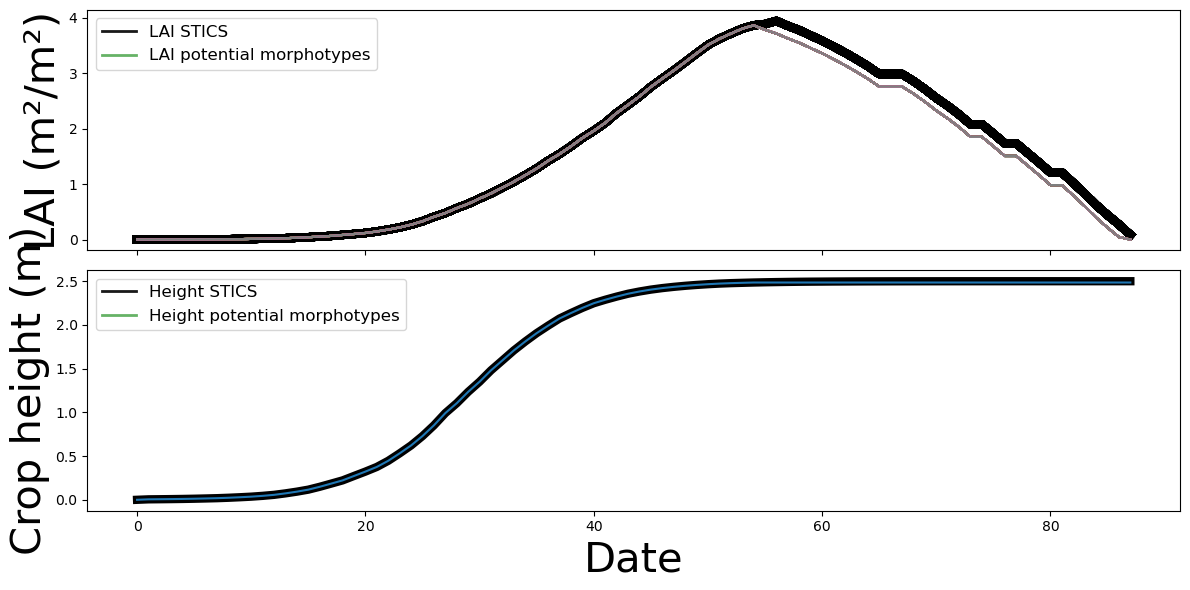

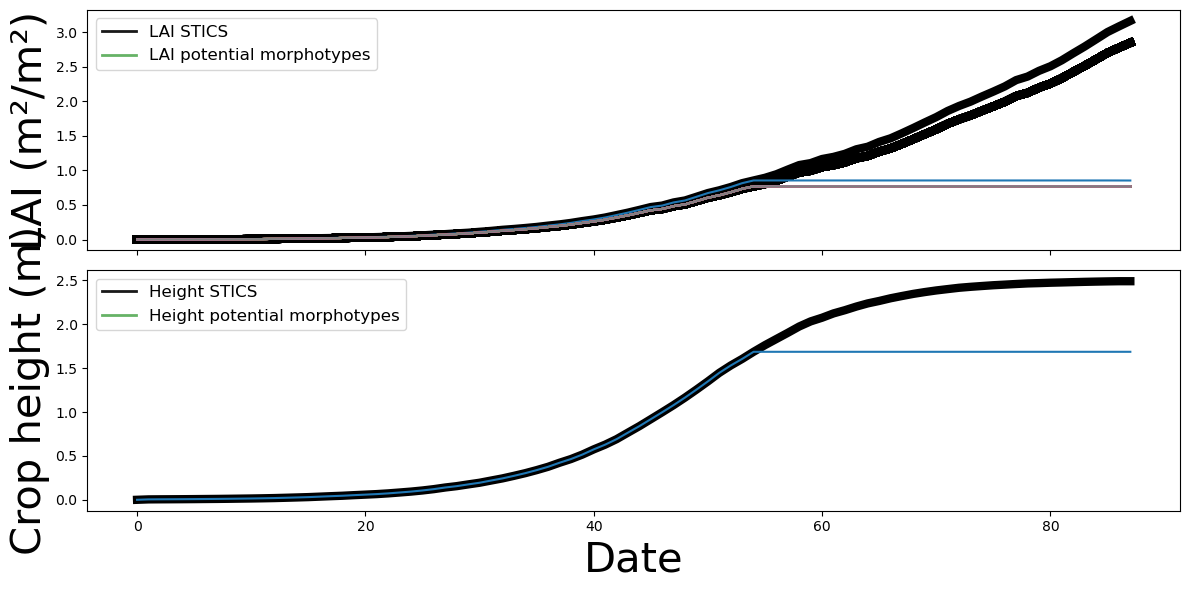

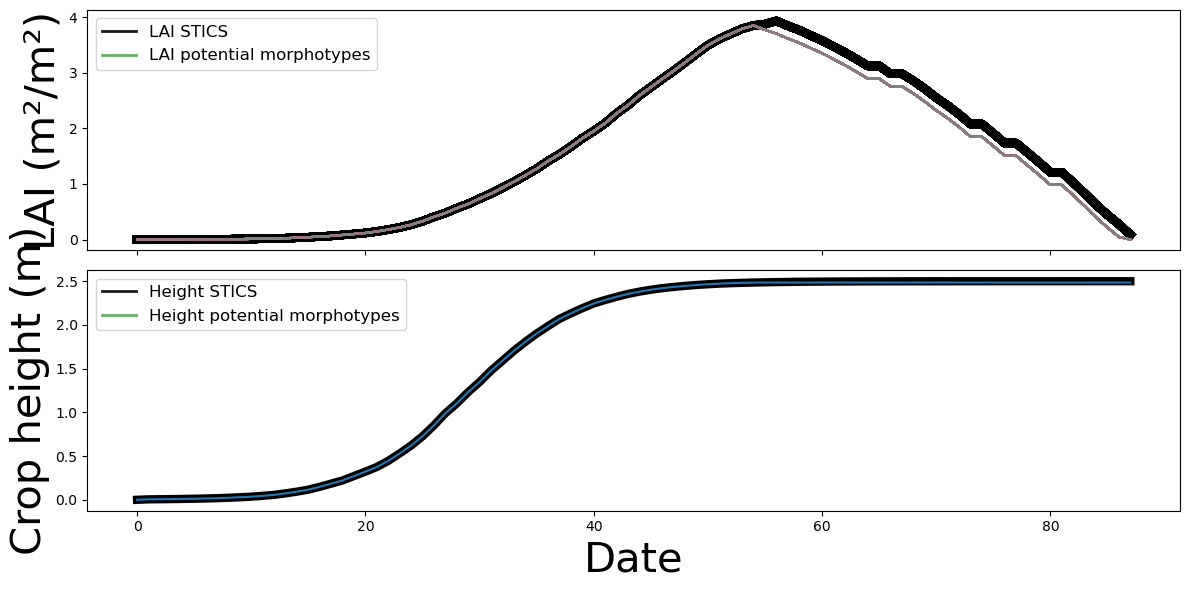

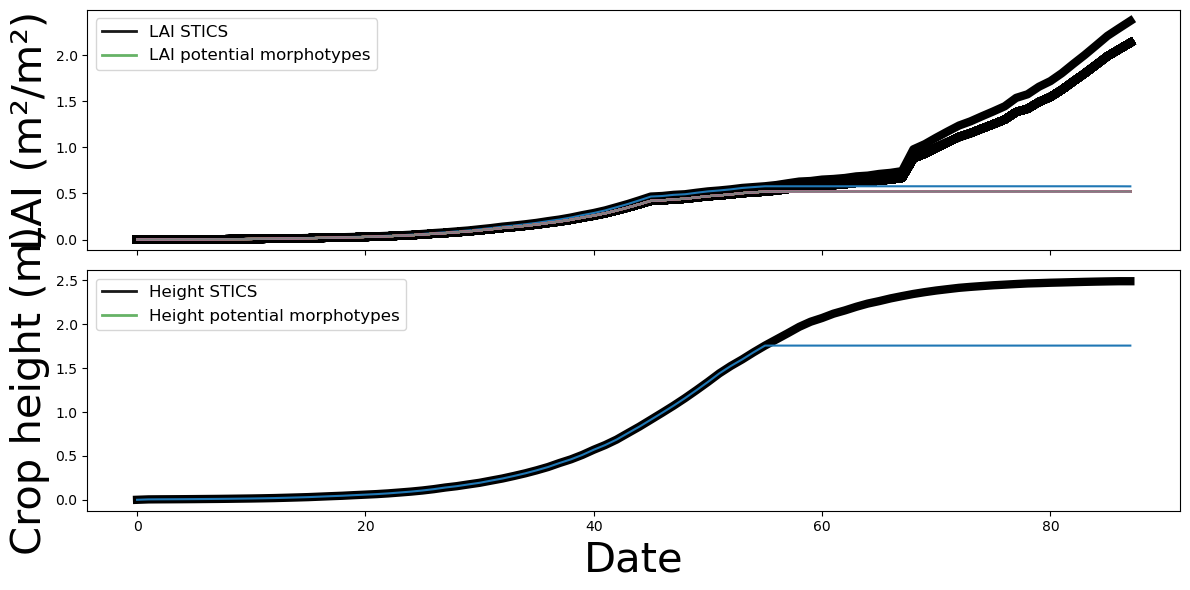

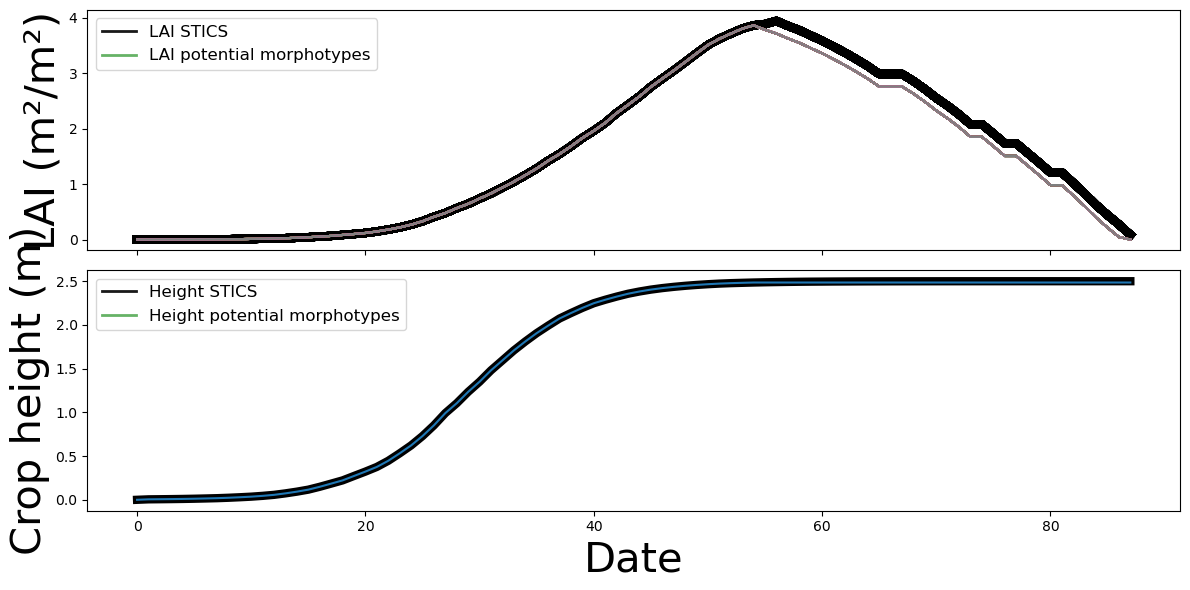

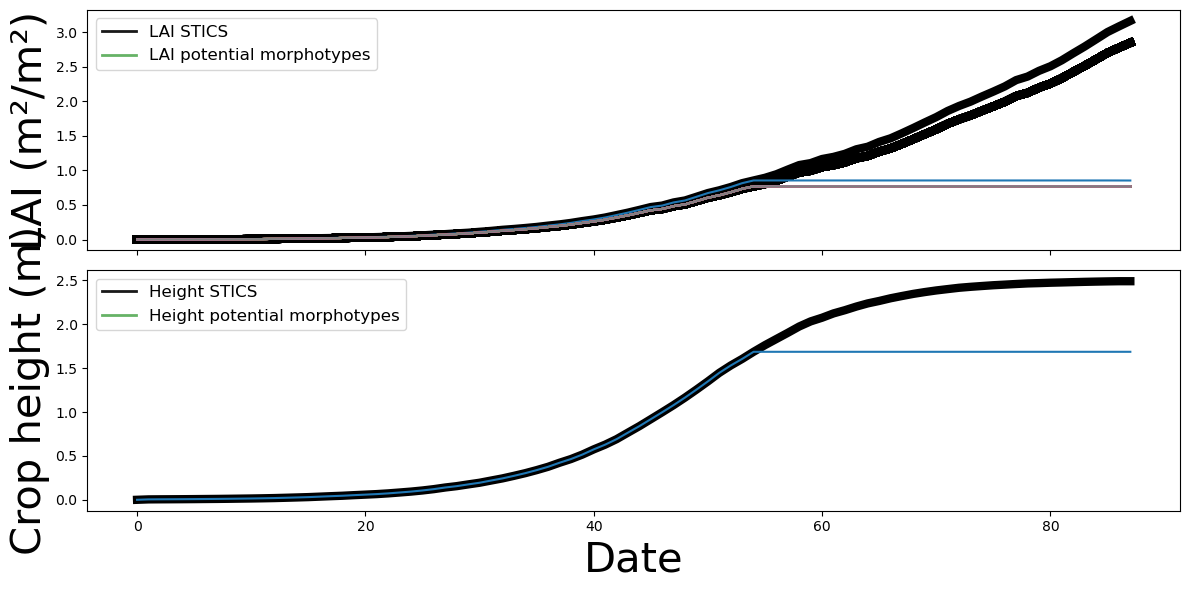

In [ ]:
def plot_constained_vs_realized_IC(dates, la, H, leaf_area_plant, height_canopy, sen_leaf_area_plant, density, stics_color="orange", archicrop_color="green"):
    
    # conversion factor
    cf_cm = 100

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)  # 1 row, 2 columns
    axes[0].plot(dates, [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=stics_color, linewidth=6)
    axes[0].plot(dates, [a*density/cf_cm**2 for a in la]) # , color=archicrop_color, alpha=0.6)
    # axes[0].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[0].set_ylabel("LAI (m²/m²)", fontsize=20)

    legend_elements_lai = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='LAI STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='LAI potential morphotypes')
    ]
    axes[0].legend(handles=legend_elements_lai, loc=2, prop={'size': 12})

    axes[1].plot(dates, [h/cf_cm for h in height_canopy], color=stics_color, linewidth=6)
    axes[1].plot(dates, [h/cf_cm for h in H]) #, color=archicrop_color, alpha=0.6)
    # axes[1].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[1].set_xlabel("Date", fontsize=20)
    axes[1].set_ylabel("Crop height (m)", fontsize=20)

    legend_elements_height = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='Height STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='Height potential morphotypes')
    ]
    axes[1].legend(handles=legend_elements_height, loc=2, prop={'size': 12})

    # Adjust layout
    plt.tight_layout()

    # Save figure
    # plt.savefig(f"../figures/plot_constrained_vs_realized_IC.png", dpi=1000)

    # Show the plot
    plt.show()

for u,usm in enumerate(usms_str):
    for a,algo in enumerate(algos):
        for p,plant in enumerate(plants):
            plot_constained_vs_realized_IC(dates, realized_la[usm][algo][plant], realized_h[usm][algo][plant], leaf_area_plant[usm][algo][plant], height_canopy[usm][algo][plant], sen_leaf_area_plant[usm][algo][plant], density[usm][algo][plant], stics_color="black")

In [11]:
# Energy in Caribu : MJ.day-1
# Irradiance in Caribu : MJ.m[leaf]-2.day-1
# Incident PAR in STICS : MJ.m[soil]-2.day-1
# Absorbed PAR in STICS : MJ.m[soil]-2.day-1

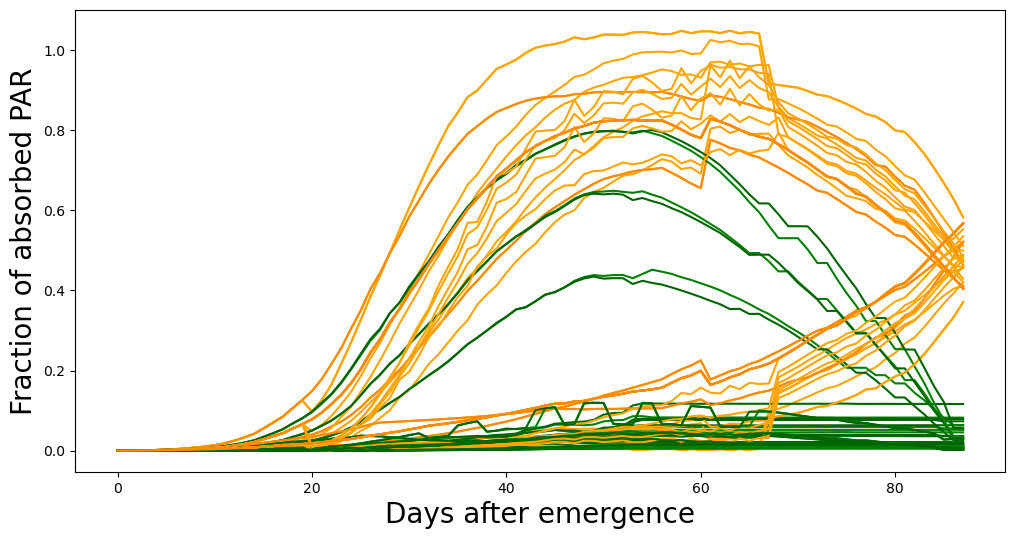

In [50]:
def plot_faPAR_algos_IC(dates, nrj_crop, par_stics):

    colors = {
        'STICS' : {'Beer': 'darkorange',
                   '2.5D': 'orange'},
        '3D' : {'Beer': 'darkgreen',
                '2.5D': 'green'}
    }

    # Plotting the envelope along with individual curves for context
    fig, ax = plt.subplots(figsize=(12, 6))
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            for p,plant in algo.items():
                ax.plot(dates, plant, color=colors['3D'][a], label=f'3D {a}') #, color=archicrop_color, alpha=0.4, label="ArchiCrop x Caribu")
                ax.plot(dates, par_stics[u][a][p], color=colors['STICS'][a], label=f"STICS {a}")

    # Labels and legend
    # ax.set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    ax.set_xlabel("Days after emergence", fontsize=20) 
    ax.set_ylabel("Fraction of absorbed PAR", fontsize=20)
    # ax.legend()

    # Save figure
    plt.savefig(f"../figures/plot_faPAR_algos_IC.png", dpi=1000)

    plt.show()

plot_faPAR_algos_IC(dates, nrj_crop, par_stics)

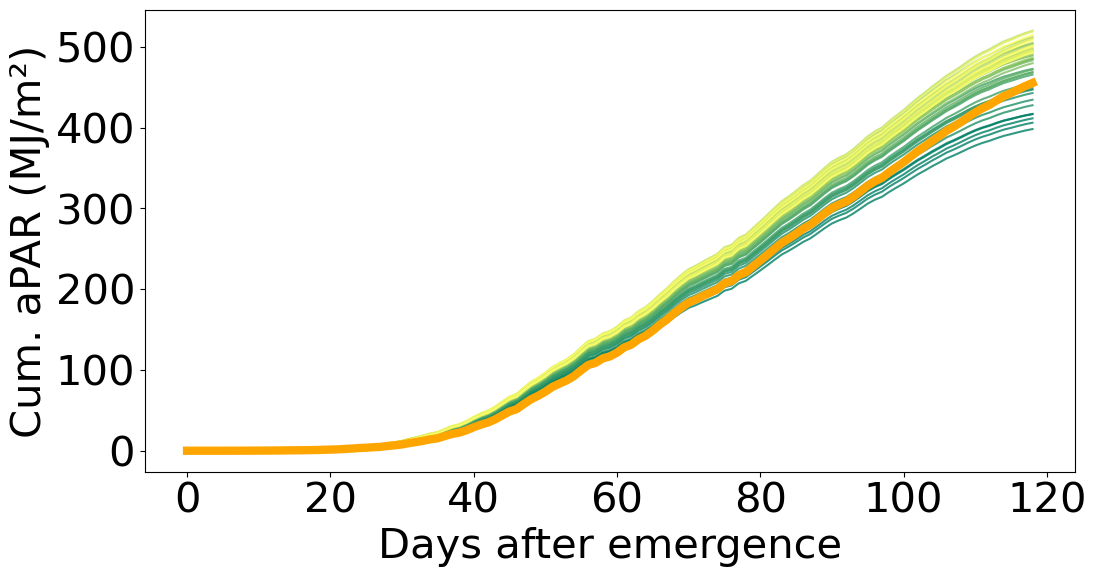

In [18]:
cumsum_nrj_per_plant(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

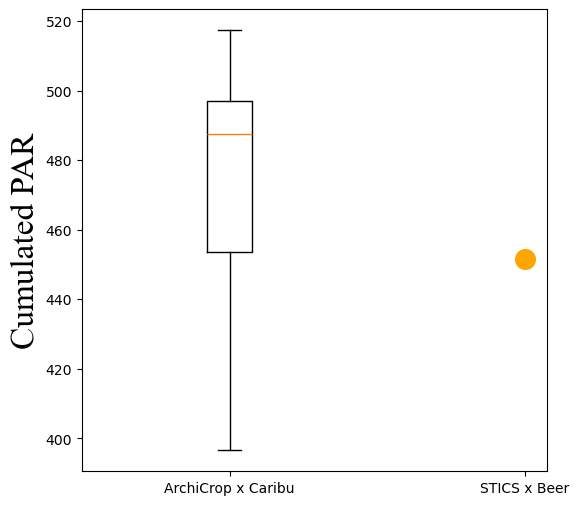

In [19]:
sum_nrj_per_plant(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

In [20]:
cf_cm = 100
lai = [la *density/cf_cm**2 for la in leaf_area_plant]

# plot_faPAR_per_leaf_parameter(lai, nrj_leaf, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

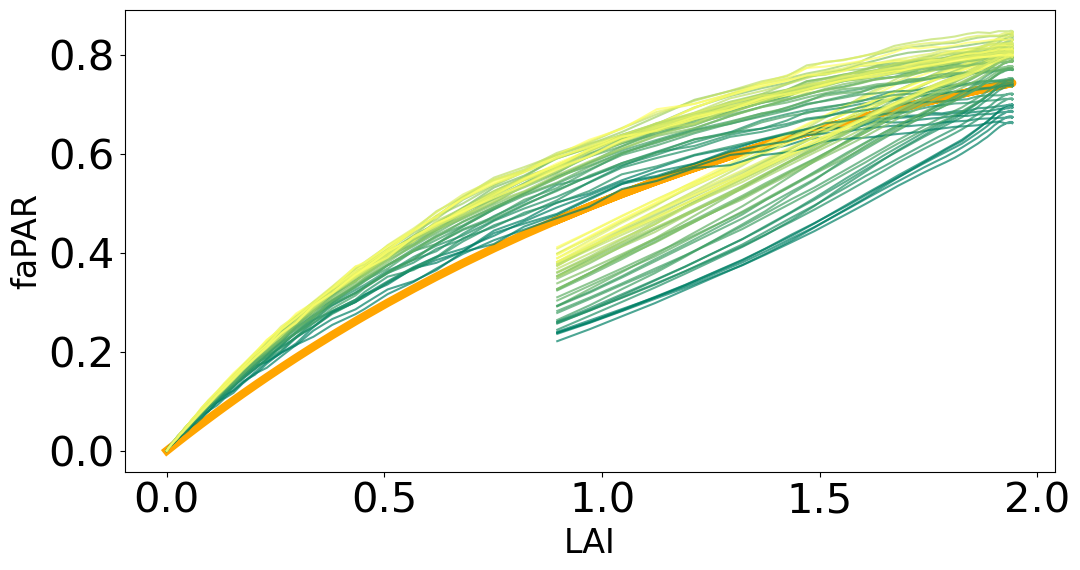

In [21]:
lai = [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)]
plot_faPAR_lai_parameter(lai, nrj_crop, par_incident, par_stics, density, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

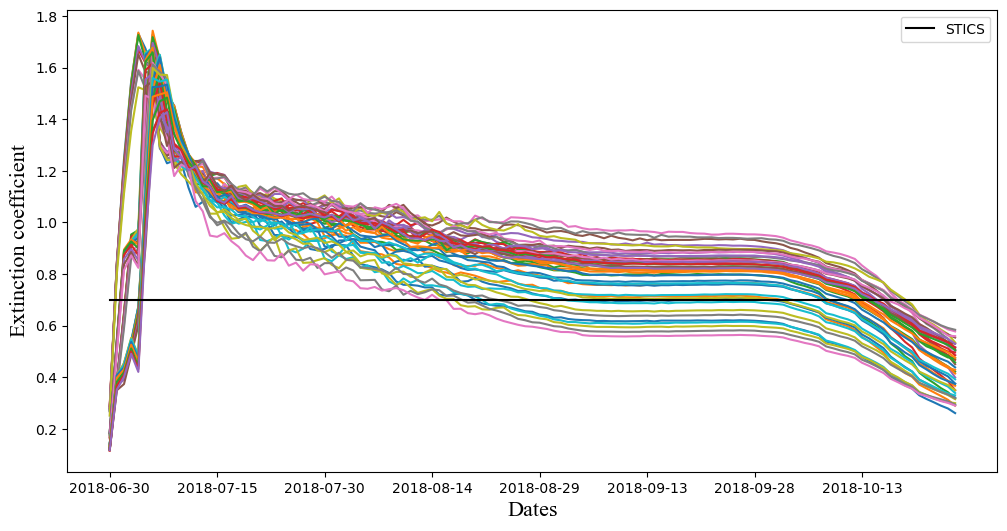

In [22]:
extinP_sorghum = 0.7

lai = [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)]
extin_coefs = compute_extinction_coef(nrj_crop, par_incident, lai)
plot_extinction_coef(extinP_stics=extinP_sorghum, extin_coefs=extin_coefs, dates=dates)

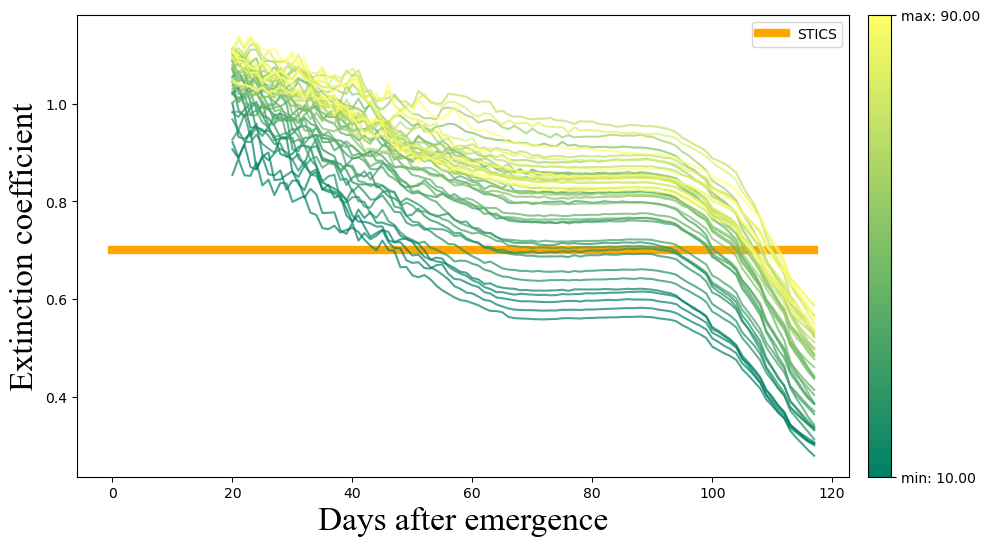

In [23]:
plot_extinction_coef_dyn_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color=stics_color)

In [24]:
theta=60
print(-0.000059*theta**2+ 0.0090*theta+ 0.55)

0.8775999999999999


k = -0.000059 theta^2 + 0.0090 theta + 0.55
R2 =  0.9036311345602013


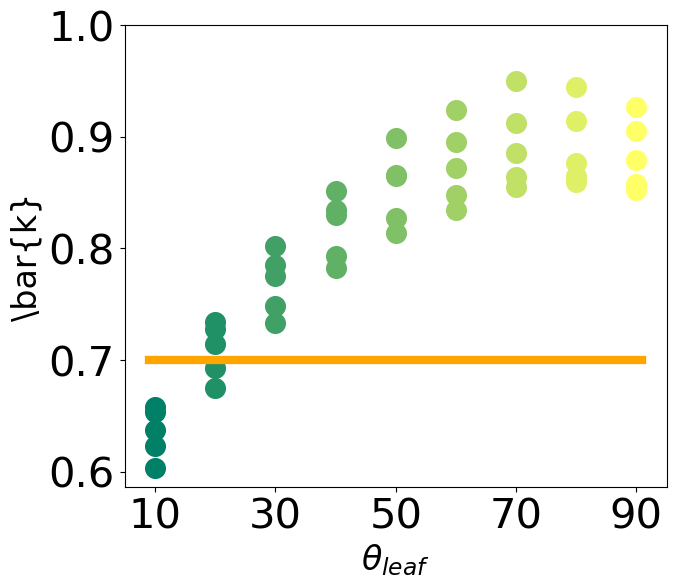

k = -0.0048 N + 0.9108
R2 =  0.0893644255465168


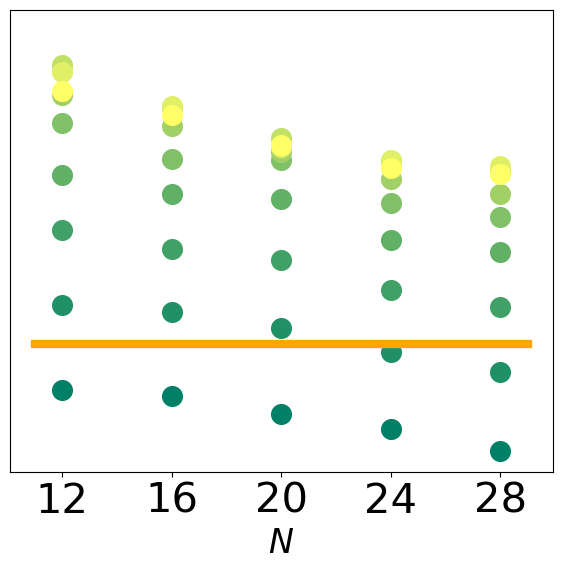

In [25]:
plot_extinction_coef_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color=stics_color)
plot_extinction_coef_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, nb_phy, 'nb_phy', insertion_angle, archicrop_color, stics_color=stics_color)

k = 0.5555 + 0.1263*log(theta) + -0.1205*LAIgreen + -0.9696*pLAIsen
R2 =  0.9384057705963413


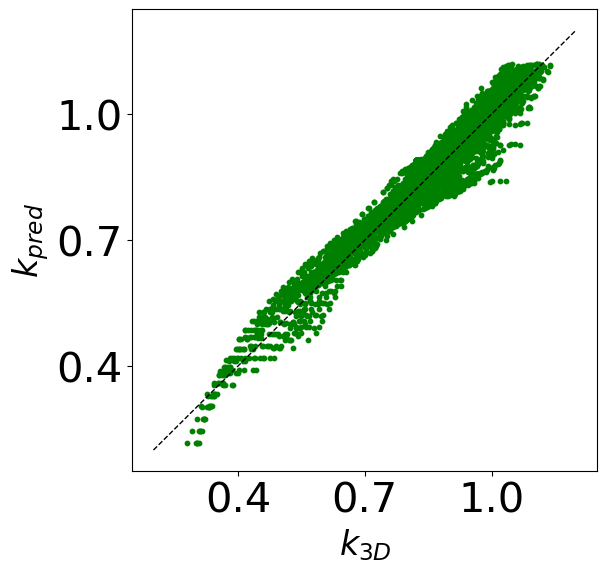

In [41]:
from sklearn.feature_selection import f_regression

start = 20
end = -1

L1 = len(extin_coefs.values())
lai_tot = np.array([la*density/cf_cm**2 for la in leaf_area_plant[start:end]]*L1)
lai_green = np.array([(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant[start:end], sen_leaf_area_plant[start:end])]*L1)
# percent_green = np.array([green/tot for tot, green in zip(lai_tot, lai_green)])
percent_sen = np.array([1-green/tot for tot, green in zip(lai_tot, lai_green)])
L2 = len(leaf_area_plant[start:end])
theta = np.array(list(insertion_angle.values())).repeat(L2)
theta_log = np.array([math.log(x) for x in insertion_angle.values()]).repeat(L2)
nb = np.array(list(nb_phy.values())).repeat(L2)
k = np.array([ec[start:end] for ec in list(extin_coefs.values())]).flatten() # 2D array 

# print(len(theta_log), len(nb), len(lai_green), len(percent_green))

# X = np.column_stack((theta_log, nb, lai_green, percent_green))
X = np.column_stack((theta_log, lai_green, percent_sen))
# X = np.column_stack((theta_log, lai_green))
model = LinearRegression(fit_intercept=True).fit(X, k)
# model = f_regression(X, y)

# equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*N + {model.coef_[2]:.4f}*LAIgreen + {model.coef_[3]:.4f}*pLAIgreen"
equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*LAIgreen + {model.coef_[2]:.4f}*pLAIsen"
# equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*LAIgreen"
print(equation)

fit_line = model.predict(X)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(k, fit_line, color="green", s=10)
ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$k_{3D}$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)
ax.set_xticks([0.4,0.7,1.0])
ax.set_yticks([0.4,0.7,1.0])
ax.tick_params(axis='both', labelsize=30)

r2 = r2_score(k, fit_line)
# r2 = model.score()
print("R2 = ", r2)

# Save figure
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"../figures/", exist_ok=True)  
plt.savefig(f"../figures/plot_linear_model.png", dpi=1000)

# Export and reimport table with data

k = 0.5555 + 0.1263*log(theta) + -0.1205*LAIgreen + -0.9696*LAIgreen*pLAIsen
R2 =  0.9384057705963413


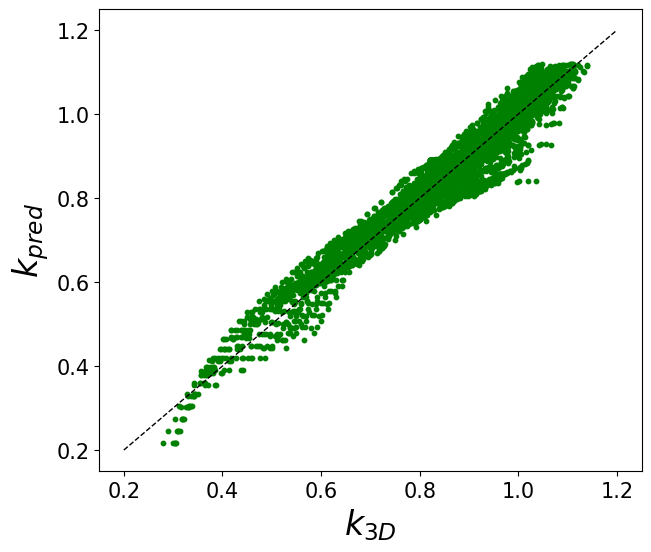

In [27]:
# theta = X[:,0]
theta_log = np.array([math.log(x) for x in theta])
L = X[:,1]
p = X[:,2]

# z = (L != 0).astype(float)  # conditional intercept
# X_model = np.column_stack([
#     z,
#     theta,
#     L,
#     p
# ])

# interaction = L * p

X_model = np.column_stack([
    theta_log,
    L,
    p,
    # interaction
])

model = LinearRegression(fit_intercept=True)
model.fit(X_model, k)

x0, x1, x2 = model.coef_

equation = f"k = {model.intercept_:.4f} + {x0:.4f}*log(theta) + {x1:.4f}*LAIgreen + {x2:.4f}*LAIgreen*pLAIsen"
# equation = f"k = {model.intercept_} + {x0:.4f}*log(theta) + {x1:.4f}*LAIgreen"
print(equation)

fit_line = model.predict(X_model)

r2 = r2_score(k, fit_line)
print("R2 = ", r2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(k, fit_line, color="green", s=10)
ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$k_{3D}$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)
ax.tick_params(axis='both', labelsize=15)

Text(0, 0.5, '$k_{pred}$')

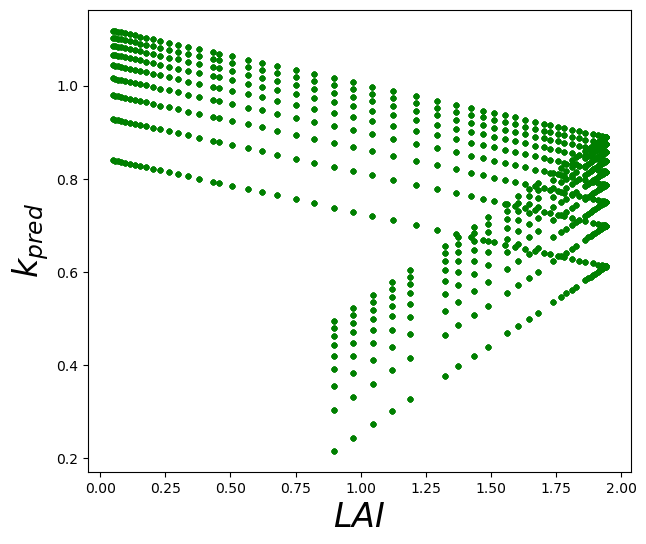

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(L, fit_line, color="green", s=10)
# ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$LAI$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)

Text(0, 0.5, '$k_{pred}$')

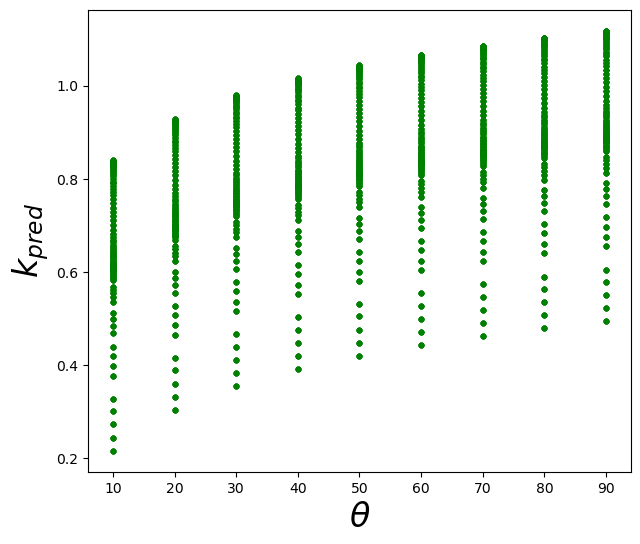

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(theta, fit_line, color="green", s=10)
# ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$\theta$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)

In [30]:
from sklearn.feature_selection import f_regression

f, p = f_regression(X, k)

print(f)
print(p)

[1644.52469394 1106.87669393 3463.99481312]
[7.63368172e-306 9.80977664e-217 0.00000000e+000]


In [31]:
from scipy.stats import shapiro
residuals = k - fit_line
stat, p_value = shapiro(residuals)
print("Shapiro p-value:", p_value)

Shapiro p-value: 8.35567855482595e-27


In [32]:
# Residuals
residuals = k - fit_line
n = len(k)

# Number of parameters (coefficients + intercept)
p = len(X[0])+2

# Estimate variance (MLE version!)
sigma2 = np.sum(residuals**2) / n

# Log-likelihood under Gaussian errors
# log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(residuals**2) / (2 * sigma2)
# log_likelihood = -n / 2 * np.log(2 * np.pi * sigma2) - (1 / (2 * sigma2)) * np.sum((y - predictions) ** 2)
log_likelihood = -n/2 * (np.log(2 * np.pi * sigma2) + 1)

# BIC
bic = -2 * log_likelihood + p * np.log(n)

print("BIC:", bic)

BIC: -15661.810991248032


In [33]:
# Residuals
n = len(k)
# residuals = [extinP_sorghum]*n - fit_line
residuals = k - [extinP_sorghum]*n

# Number of parameters (coefficients + intercept)
p = 1

# Estimate variance (MLE version!)
sigma2 = np.sum(residuals**2) / n

# Log-likelihood under Gaussian errors
log_likelihood = -n/2 * (np.log(2 * np.pi * sigma2) + 1)
# log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(residuals**2) / (2 * sigma2)

# BIC
bic = -2 * log_likelihood + p * np.log(n)

print("BIC:", bic)

BIC: -1662.849164073462


In [34]:
# --- Compute residuals of each run vs fitted line ---
residuals = k - fit_line  # shape (n_runs, n_timesteps)
# Standard deviation across runs at each time step
std_residuals = residuals.std(axis=0)
# Compute residual sum of squares (RSS)
rss = np.sum(residuals**2)
# Number of data points
n = len(k)   
p = 6        

# BIC
bic = n * np.log(rss/n) + p * np.log(n)
print(f"BIC lm = {bic:.2f}")

BIC lm = -28168.46


In [35]:
# --- Compute residuals of each run vs fitted line ---
residuals = k - [extinP_sorghum]*len(k)  # shape (n_runs, n_timesteps)
# Standard deviation across runs at each time step
std_residuals = residuals.std(axis=0)
# Compute residual sum of squares (RSS)
rss = np.sum(residuals**2)
# Number of data points
n = len(k)   
p = 1        

# BIC
bic = n * np.log(rss/n) + p * np.log(n)
print(f"BIC const = {bic:.2f}")

BIC const = -14177.89


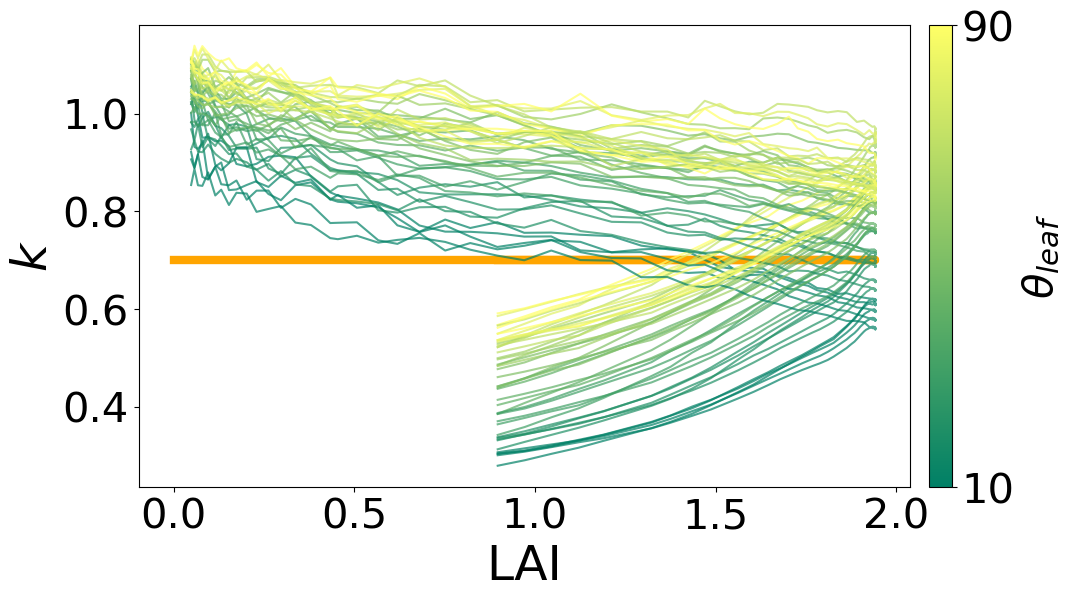

In [36]:
plot_extinction_coef_lai_parameter(extinP_sorghum, extin_coefs, lai, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color='orange')

k_growth = -0.120*LAI + 1.026
k_sen = 0.311*LAI + 0.143


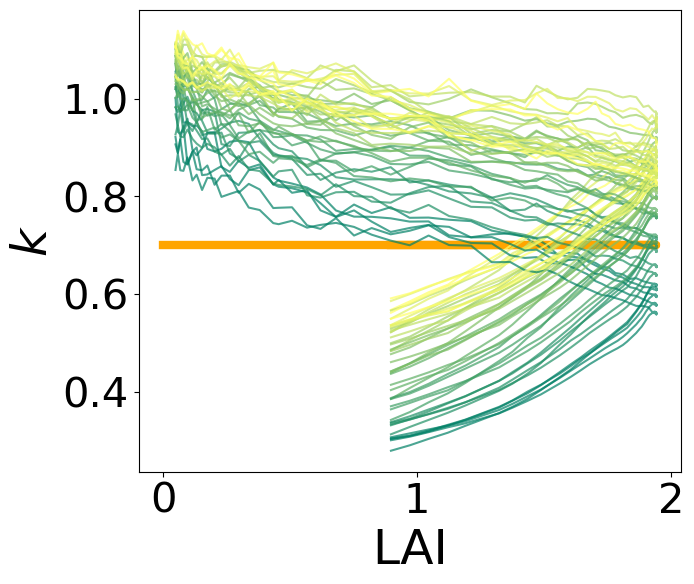

In [37]:
def plot_extinction_coef_lai_parameter(extinP_stics, extin_coefs, lai, nrj_crop, archi, parameter, parameter_name, insertion_angle, archicrop_color, stics_color):

    start = 20
    end = len(lai)-1 #34
    lai_trunc = lai[start:end]


    fig, ax = plt.subplots(figsize=(7, 6))
    # lai = [la*density/10000 for la in leaf_area_plant]
    # Normalize parameter values to [0, 1] for colormap
    param_values = np.array([parameter[k] for k in nrj_crop])
    norm = plt.Normalize(param_values.min(), param_values.max())
    cmap = plt.get_cmap('summer')
    # cmap = (mpl.colors.ListedColormap(['green', 'orange', '#BF864D']))
    # bounds = [param_values.min(), param_values.min()+(param_values.max()-param_values.min())/3, param_values.min()+2*(param_values.max()-param_values.min())/3, param_values.max()]
    # norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    ax.plot(lai[:end], [extinP_stics]*len(lai[:end]), color=stics_color, linewidth=6, label="STICS")

    regressions = {}

    # Plot each curve with color from colormap
    for k,curve in extin_coefs.items():
        if parameter[k] in regressions:
            regressions[parameter[k]].append(curve[start:end])
        else:
            regressions[parameter[k]] = [curve[start:end]]
        color = cmap(norm(parameter[k]))
        ax.plot(lai[start:end], curve[start:end], color=color, alpha=0.7)

    t = 80
    slopes_growth = []
    slopes_sen = []
    intercepts_growth = []
    intercepts_sen = []
    
    for parameter_value, curves in regressions.items():
        mean_series = np.array(curves).mean(axis=0)
    
        model = LinearRegression().fit(np.array(lai_trunc[:t]).reshape(-1,1), mean_series[:t])
        slope = model.coef_[0]
        slopes_growth.append(slope)
        intercept = model.intercept_
        intercepts_growth.append(intercept)
        # equation = f"extinction coef = {slope:.3f}*LAI + {intercept:.3f}"
        # print(equation)
        # fit_line = model.predict(np.array(lai_trunc).reshape(-1,1))
    
        model = LinearRegression().fit(np.array(lai_trunc[t:]).reshape(-1,1), mean_series[t:])
        slope = model.coef_[0]
        slopes_sen.append(slope)
        intercept = model.intercept_
        intercepts_sen.append(intercept)
        # equation = f"extinction coef = {slope:.3f}*LAI + {intercept:.3f}"
        # print(equation)
        # fit_line = model.predict(np.array(lai_trunc).reshape(-1,1))
       
        # plt.plot([lai_trunc[0],lai_trunc[0]], [0,1.2], alpha=0.3, color="green")
        # plt.plot(lai_trunc, mean_series, color="black", linewidth=2, label="Mean series")
        # color = cmap(norm(parameter_value))
        # ax.plot(lai_trunc, fit_line, color='black', linewidth=3, linestyle="-")
        # ax.plot(lai_trunc, fit_line, color=color, linewidth=2, linestyle="--", label=f"Linear regression for {parameter_name}={parameter_value}")

    slope_growth_avg = np.mean(slopes_growth)
    intercept_growth_avg = np.mean(intercepts_growth)
    equation = f"k_growth = {slope_growth_avg:.3f}*LAI + {intercept_growth_avg:.3f}"
    print(equation)
    # fit_line = [slope_growth_avg*l+intercept_growth_avg for l in lai_trunc[:t]]
    # r2 = r2_score(k[:t], fit_line)
    # print("R2 = ", r2)
    slope_sen_avg = np.mean(slopes_sen)
    intercept_sen_avg = np.mean(intercepts_sen)
    equation = f"k_sen = {slope_sen_avg:.3f}*LAI + {intercept_sen_avg:.3f}"
    print(equation)
    # fit_line = [slope_sen_avg*l+intercept_sen_avg for l in lai_trunc[t:]]
    # r2 = r2_score(k[t:], fit_line)
    # print("R2 = ", r2)
    
    # ax.set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    ax.set_xlabel("LAI", fontsize=35) 
    ax.set_ylabel(r"$k$", fontsize=35)
    ax.set_xticks([0,1,2])
    ax.tick_params(axis='both', labelsize=30)
    # ax.set_title(f"Extinction coefficient as a function of {parameter_name}", fontsize=16, fontname="Times New Roman")

    # Add colorbar legend
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
    # cbar.set_label(r"$\theta_{leaf}$", fontsize=30)
    # cbar.set_ticks([param_values.min(), param_values.max()])
    # cbar.set_ticklabels([f"{param_values.min()}", f"{param_values.max()}"], fontsize=30)


    # ax.legend(fontsize=14)

    # Save figure
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"../figures/", exist_ok=True)  
    plt.savefig(f"../figures/plot_extin_coef_LAI_{parameter_name}.png", dpi=1000)

    plt.show()

plot_extinction_coef_lai_parameter(extinP_sorghum, extin_coefs, lai, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color='orange')

In [38]:
"""
# vertical light interception
cs, ei, df = illuminate(scene, scene_unit='cm')
cs.plot(ei)


# diffuse light interception
sources = skys.sky_sources()
cs, ei, df = illuminate(scene, light=sources, scene_unit='cm')
cs.plot(ei)

# get score per plant
def score(res):
    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),
                              'area': res.area.sum()})
df['nump']=nump
df.groupby('nump').apply(score)
"""

"\n# vertical light interception\ncs, ei, df = illuminate(scene, scene_unit='cm')\ncs.plot(ei)\n\n\n# diffuse light interception\nsources = skys.sky_sources()\ncs, ei, df = illuminate(scene, light=sources, scene_unit='cm')\ncs.plot(ei)\n\n# get score per plant\ndef score(res):\n    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),\n                              'area': res.area.sum()})\ndf['nump']=nump\ndf.groupby('nump').apply(score)\n"